# Read the output of genZWPusingCylMaps.

## Simiar to readZWPs that read the outputs based on the main .fits file (not already cylindrically projected via DRM)
## Use this file to get the time evolution map only...

### The .npz files contain ['wind_prof_raw', 'date_list', 'delta_t_arr', 'crit_lat'].



In [1]:
'''
shifted_f1=[shifted_f1], shifted_f2=[shifted_f1], long_shift_applied=[long_shift_applied],
wind_slide=[rough_wind_full], w_slide_err=[err_velocity_slide], w_slide_fwhm=[fwhm_array_slide],
wind_noslide=[zwp_5microns], w_noslide_err=[err_velocity], w_npslide_fwhm=[fwhm_array],
lat_array_used=[lat_array_use], long_array_use=[long_array_use], margin_applied_in_func_shifted=[margin_applied_in_func_shifted],
date_list = date_meta_list[test_i], pair_names = pair_names, delta_t_arr = [delta_t], crit_lat=[critical_lat]
'''

'\nshifted_f1=[shifted_f1], shifted_f2=[shifted_f1], long_shift_applied=[long_shift_applied],\nwind_slide=[rough_wind_full], w_slide_err=[err_velocity_slide], w_slide_fwhm=[fwhm_array_slide],\nwind_noslide=[zwp_5microns], w_noslide_err=[err_velocity], w_npslide_fwhm=[fwhm_array],\nlat_array_used=[lat_array_use], long_array_use=[long_array_use], margin_applied_in_func_shifted=[margin_applied_in_func_shifted],\ndate_list = date_meta_list[test_i], pair_names = pair_names, delta_t_arr = [delta_t], crit_lat=[critical_lat]\n'

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import scipy as sp
import glob
import pandas as pd
from matplotlib.gridspec import GridSpec
import arviz as az
import pymc as pm
import matplotlib.colors as mcolors
import matplotlib as mpl


# main class where these functions are dumped:
from zonalwindfunctions import ZWP_Class

print(matplotlib.get_backend())


module://matplotlib_inline.backend_inline


In [3]:
long_res, lat_res = 360, 180
long_array, lat_array = np.linspace(360, 0,long_res), np.linspace(-90, 90,lat_res)
long_array_hi, lat_array_hi = np.linspace(360, 0,long_res*2), np.linspace(-90, 90,lat_res*2)
R_J = 71492e3 # m
R_J_p = 66854e3 # m

def DeleteElement(index_to_exclude):
    '''
    Useful to delete specific wind fields. Based on discretion; documentation is advised.
    '''
    del corr1D_list[index_to_exclude]
    del corr1D_err_list[index_to_exclude]
    del corr1D_fwhm_list[index_to_exclude]
    
    del corr_slide_list[index_to_exclude]
    del corr_slide_err_list[index_to_exclude]
    del corr_slide_fwhm_list[index_to_exclude]

    del lat_array_used[index_to_exclude]
    del long_array_use[index_to_exclude]

    del margin_applied_in_func_shifted[index_to_exclude]
    
    del date_list[index_to_exclude]
    del delta_t_list[index_to_exclude]
    del crit_lat_list[index_to_exclude]
    del pair_name_list[index_to_exclude]

def generateArrays(output_file_list):

    # define relevant array lists...
    corr1D_list = []
    corr1D_err_list = []
    corr1D_fwhm_list = []
    corr_slide_list = []
    corr_slide_err_list = []
    corr_slide_fwhm_list = []
    lat_array_used = []
    long_array_use = []
    margin_applied_in_func_shifted = []
    date_list = []
    delta_t_list = []
    crit_lat_list = []
    pair_name_list = []

    for i_f, f in enumerate(output_file_list):
        npzfile = np.load(f)
        
        # Correlation with no sliding window
        corr1D_list.append(npzfile['wind_noslide']) # smoothed with savgol jet_width=4, poly_order=3
        corr1D_err_list.append(npzfile['w_noslide_err']) # not smoothed - retains generality
        corr1D_fwhm_list.append(npzfile['w_npslide_fwhm'])

        # Correlation with 50˚ sliding window
        corr_slide_list.append(npzfile['wind_slide'])
        corr_slide_err_list.append(npzfile['w_slide_err'])
        corr_slide_fwhm_list.append(npzfile['w_slide_fwhm'])

        # Specific latitude array that was used - removes the need to interpolate later
        lat_array_used.append(npzfile['lat_array_used'])
        long_array_use.append(npzfile['long_array_use'])

        margin_applied_in_func_shifted.append(npzfile['margin_applied_in_func_shifted'])

        date_list.append(npzfile['date_list'])
        delta_t_list.append(npzfile['delta_t_arr'])
        crit_lat_list.append(npzfile['crit_lat'])
        pair_name_list.append(npzfile['pair_names'])

        print(npzfile['pair_names'], npzfile['date_list'], npzfile['delta_t_arr'], 'shape: ', len(npzfile['wind_noslide'][0]), i_f)
    
    return {
        "corr1D_list": corr1D_list,
        "corr1D_err_list": corr1D_err_list,
        "corr1D_fwhm_list": corr1D_fwhm_list,
        "corr_slide_list": corr_slide_list,
        "corr_slide_err_list": corr_slide_err_list,
        "corr_slide_fwhm_list": corr_slide_fwhm_list,
        "lat_array_used": lat_array_used,
        "long_array_use": long_array_use,
        "margin_applied_in_func_shifted": margin_applied_in_func_shifted,
        "date_list": date_list,
        "delta_t_list": delta_t_list,
        "crit_lat_list": crit_lat_list,
        "pair_name_list": pair_name_list,
    }
    
def getFFTfields(years, dataset, test_lat=1000):
    time_signal_length__per_lat = len(years)
    sampling_interval           = np.mean(np.diff(years)) #* 365.25*24*3600 # Try converting to seconds. This last factor converts the smapling difference from years to seconds
    sampling_frequency          = 1/sampling_interval
    nyquist                     = sampling_frequency/2

    print(time_signal_length__per_lat)
    print(sampling_interval          )
    print(sampling_frequency         )
    print(nyquist                    )

    print(dataset[:, test_lat])

    FFT_field = np.zeros_like(dataset)
    Fv_field  = np.zeros((len(years)//2 + 1, dataset.shape[-1]))
    Iv_field  = np.zeros((len(years)//2 + 1, dataset.shape[-1]))

    for f in range(dataset.shape[-1]):
        # Normalized FFT
        FFT_field[:, f] = np.fft.fft(dataset[:, f]) / time_signal_length__per_lat
        # Frequency vector (one-sided)
        Fv_field[:, f] = np.linspace(0, 1, time_signal_length__per_lat//2 + 1) * nyquist
        Iv_field[:, f] = np.arange(len(Fv_field[:, f]))
        
        # same as above but just doing it for the last latitude for explanatory purposes...
        FTs = np.fft.fft(dataset[:, test_lat]) / time_signal_length__per_lat
        Fv = np.linspace(0, 1, time_signal_length__per_lat//2 + 1) * nyquist
        Iv = np.arange(len(Fv))

    return FFT_field, Fv_field, FTs, Iv, Fv


def lat_label(val):
    return f"{abs(val):.0f}°{'S' if val < 0 else 'N'}"


In [4]:
tt = [2.4, 3.2, 6.9, 7.2, 9.8]
tt2 = np.array([-79.9, -79.8, -79.7, -79.6, -79.5, -0.2, -0.1, 0.0, 0.1, 0.2, 79.5, 79.6, 79.7, 79.8, 79.9])
# print(np.where(np.isclose(0.0, 0.001 ,rtol=1e-3)))
K = -5.1

print(ZWP_Class.closestIndex2Lat(tt2, K))

(np.int64(5), np.float64(-0.2))


In [5]:

year = '2018'
output_path = '/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/' + year + '/'
output_file_list = glob.glob(output_path + '*.npz')

# output_file_list = [f for f in output_file_list if '2024nov' not in f]

for f in output_file_list:
    print(f)

print(year)
print('Number of pairs originally: ', len(output_file_list))

print(np.load(output_file_list[0]))

/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2018/2018jul20_jcf0129101339_jcf0000100018.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2018/2018jul20_jcf0137501379_jcf0004900083.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2018/2018jul20_jcf0129101339_jcf0017500209.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2018/2018jul20_jcf0137501379_jcf0000100018.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2018/2018jul20_jcf0137501379_jcf0017500209.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2018/2018jul20_jcf0129101339_jcf0004900083.npz
2018
Number of pairs originally:  6
NpzFile '/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2018/2018jul20_jcf0129101339_jcf0000100018.npz' with keys: shifted_f1, shifted_f2, long_shift_applied, wind_slide, w_slide_err...


In [6]:
frame2024 = generateArrays(output_file_list=output_file_list) # frame2024 is an old name but used through just to be clear...

print(len(frame2024["corr1D_list"]), len(frame2024["corr_slide_list"]))


'''
Load some HST data for comparison and get the appropriate ∆t for the case currently being used.
'''

hst_wind_1D = np.genfromtxt('Simon+2015_ZWP_HST.csv', delimiter=",", dtype=None, encoding=None, names=True)[:]
opal_nov_2024_df = pd.read_excel('OPAL/2024nov_jup_502.xlsx')

# convert HST planetographic latitudes to planetocentric
centric_lat_HST = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, opal_nov_2024_df['LAT']))
centric_lat_HST_2015 = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, hst_wind_1D['y']))[:]




['jcf0129101339.cmap.gz' 'jcf0000100018.cmap.gz'] ['2018-07-20T09:08:39.59375' '2018-07-21T04:19:20.52441'] [69040.930659] shape:  360 0
['jcf0137501379.cmap.gz' 'jcf0004900083.cmap.gz'] ['2018-07-20T09:16:21.94141' '2018-07-21T04:28:23.19922'] [69121.25781] shape:  360 1
['jcf0129101339.cmap.gz' 'jcf0017500209.cmap.gz'] ['2018-07-20T09:08:39.59375' '2018-07-21T04:52:48.20312'] [71048.609369] shape:  360 2
['jcf0137501379.cmap.gz' 'jcf0000100018.cmap.gz'] ['2018-07-20T09:16:21.94141' '2018-07-21T04:19:20.52441'] [68578.582999] shape:  360 3
['jcf0137501379.cmap.gz' 'jcf0017500209.cmap.gz'] ['2018-07-20T09:16:21.94141' '2018-07-21T04:52:48.20312'] [70586.261709] shape:  360 4
['jcf0129101339.cmap.gz' 'jcf0004900083.cmap.gz'] ['2018-07-20T09:08:39.59375' '2018-07-21T04:28:23.19922'] [69583.60547] shape:  360 5
6 6


In [7]:
print(frame2024["corr_slide_list"][0][0][:, 0].shape, frame2024["corr1D_list"][0].shape, len(frame2024["corr1D_list"]), len(frame2024["corr_slide_err_list"]))

(360,) (1, 360) 6 6


In [8]:

i_specific = 1
print(output_file_list[i_specific])
print(len(frame2024["lat_array_used"]))
print(len(frame2024["lat_array_used"][i_specific][0, :]))
# No slide
# Apply Savgol filter
smooth_zwp_5microns = ZWP_Class.getSmoothedProfile(frame2024["corr1D_list"][i_specific][0, :], frame2024["lat_array_used"][i_specific][0, :], jet_width=7, poly_order=3)
smooth_err_velocity = ZWP_Class.getSmoothedProfile(frame2024["corr1D_err_list"][i_specific][0, :], frame2024["lat_array_used"][i_specific][0, :], jet_width=7, poly_order=3)

#Apply median filter
medfilt_zwp_5microns = ZWP_Class.getSmoothedProfile(frame2024["corr1D_list"][i_specific][0, :], frame2024["lat_array_used"][i_specific][0, :], filter_type='median', jet_width=4, poly_order=3)
medfilt_err_velocity = ZWP_Class.getSmoothedProfile(frame2024["corr1D_err_list"][i_specific][0, :], frame2024["lat_array_used"][i_specific][0, :], filter_type='median', jet_width=4, poly_order=3)



/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2018/2018jul20_jcf0137501379_jcf0004900083.npz
6
360


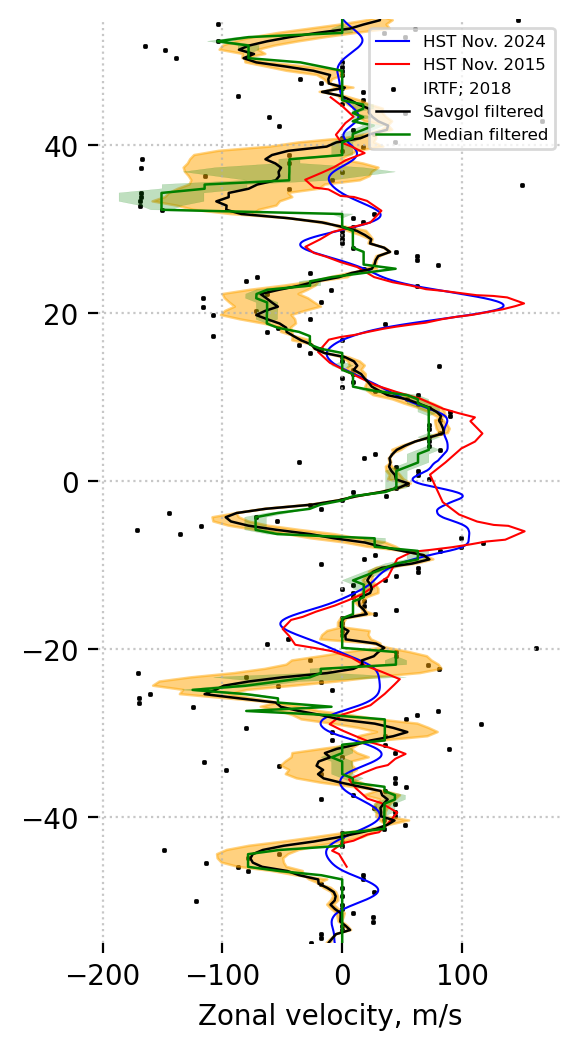

In [9]:
%matplotlib inline
y_lim_range = frame2024["crit_lat_list"][i_specific] #critical_lat - critical_lat*0.05 # -5% for aesthetics...
plt.figure(figsize=(3,6), dpi=200)

plt.plot(opal_nov_2024_df['FMZW'], centric_lat_HST, color='b', lw=0.75, label='HST Nov. 2024')
plt.plot(hst_wind_1D['x'], centric_lat_HST_2015, color='r', lw=0.75, label='HST Nov. 2015')

for z in range(len(frame2024["corr1D_list"][i_specific])):
    plt.hlines(frame2024["lat_array_used"][i_specific][0, z], min(frame2024["corr1D_list"][i_specific][0, z], frame2024["corr1D_list"][i_specific][0, z]+frame2024["corr1D_err_list"][i_specific][0, z]), max(frame2024["corr1D_list"][i_specific][0, z], frame2024["corr1D_list"][i_specific][0, z]+frame2024["corr1D_err_list"][i_specific][0, z]), colors='k', alpha=0.75, lw=0.75)
    # plt.hlines(lat_array_use[z], zwp_5microns[z]-err_velocity[z], zwp_5microns[z]+err_velocity[z], colors='k', alpha=0.75, lw=0.75)
plt.scatter(frame2024["corr1D_list"][i_specific][0, :], frame2024["lat_array_used"][i_specific][0, :], marker='s', s=1, color='k', label='IRTF; '+str(year))

plt.fill_betweenx(frame2024["lat_array_used"][i_specific][0, :], smooth_zwp_5microns-smooth_err_velocity, smooth_zwp_5microns+smooth_err_velocity, frame2024["lat_array_used"][i_specific][0, :], color='orange', lw=0.9, alpha=0.5)
plt.plot(smooth_zwp_5microns, frame2024["lat_array_used"][i_specific][0, :], color='k', lw=0.9, label='Savgol filtered')
# plt.fill_betweenx(frame2024["lat_array_used"][i_specific][0, :], zwp_5microns-err_velocity, zwp_5microns+err_velocity, frame2024["lat_array_used"][i_specific][0, :], color='orange', lw=0.9, alpha=0.5)

plt.fill_betweenx(frame2024["lat_array_used"][i_specific][0, :], medfilt_zwp_5microns-medfilt_err_velocity, medfilt_zwp_5microns+medfilt_err_velocity, frame2024["lat_array_used"][i_specific][0, :], color='g', lw=0.1, alpha=0.25)
plt.plot(medfilt_zwp_5microns, frame2024["lat_array_used"][i_specific][0, :], color='g', lw=0.9, label='Median filtered')


plt.xlabel('Zonal velocity, m/s')
# plt.xlim(-1000, 1000)
plt.ylim(-y_lim_range, y_lim_range)
plt.grid(True, 'both', ls=':', alpha=0.7)
plt.legend(loc='upper right', framealpha=0.75, fontsize=6)

plt.gca().set_frame_on(False)

plt.show()


In [10]:

# save for i_specific:
# np.savez_compressed(output_path+'../ZWP_for_ispec'+year, smooth_zwp_5microns_savgol=smooth_zwp_5microns, smooth_err_velocity_savgol=smooth_err_velocity, 
#                     medfilt_zwp_5microns=medfilt_zwp_5microns, medfilt_err_velocity=medfilt_err_velocity, lat_array_used=frame2024["lat_array_used"][i_specific][0, :])



In [11]:

# now load it all up!
ZWP_2016 = np.load(output_path+'../ZWP_for_ispec' + '2016.npz')
ZWP_2017 = np.load(output_path+'../ZWP_for_ispec' + '2017.npz')
ZWP_2018 = np.load(output_path+'../ZWP_for_ispec' + '2018.npz')
ZWP_2019 = np.load(output_path+'../ZWP_for_ispec' + '2019.npz')
ZWP_2020 = np.load(output_path+'../ZWP_for_ispec' + '2020.npz')
ZWP_2021 = np.load(output_path+'../ZWP_for_ispec' + '2021.npz')
ZWP_2022 = np.load(output_path+'../ZWP_for_ispec' + '2022.npz')
ZWP_2023 = np.load(output_path+'../ZWP_for_ispec' + '2023.npz')
ZWP_2024 = np.load(output_path+'../ZWP_for_ispec' + '2024.npz')

print(ZWP_2024.keys())
print(ZWP_2016['medfilt_zwp_5microns'].shape,
      ZWP_2017['medfilt_zwp_5microns'].shape,
      ZWP_2018['medfilt_zwp_5microns'].shape,
      ZWP_2019['medfilt_zwp_5microns'].shape,
      ZWP_2020['medfilt_zwp_5microns'].shape,
      ZWP_2021['medfilt_zwp_5microns'].shape,
      ZWP_2022['medfilt_zwp_5microns'].shape,
      ZWP_2023['medfilt_zwp_5microns'].shape,
      ZWP_2024['medfilt_zwp_5microns'].shape)


# the following will only work if everything is homogeneous (AKA, all the latitudes are of the same size - otherwise you'll have to interpolate to the 180 grid!)
ZWP_full = np.array([ZWP_2016['medfilt_zwp_5microns'], ZWP_2017['medfilt_zwp_5microns'], ZWP_2018['medfilt_zwp_5microns'], ZWP_2019['medfilt_zwp_5microns'], ZWP_2020['medfilt_zwp_5microns'], ZWP_2021['medfilt_zwp_5microns'], ZWP_2022['medfilt_zwp_5microns'], ZWP_2023['medfilt_zwp_5microns'], ZWP_2024['medfilt_zwp_5microns']])
ZWP_full_savgol = np.array([ZWP_2016['smooth_zwp_5microns_savgol'], ZWP_2017['smooth_zwp_5microns_savgol'], ZWP_2018['smooth_zwp_5microns_savgol'], ZWP_2019['smooth_zwp_5microns_savgol'], ZWP_2020['smooth_zwp_5microns_savgol'], ZWP_2021['smooth_zwp_5microns_savgol'], ZWP_2022['smooth_zwp_5microns_savgol'], ZWP_2023['smooth_zwp_5microns_savgol'], ZWP_2024['smooth_zwp_5microns_savgol']])
year_arr = np.array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

type_of_error = 'smooth_err_velocity_savgol'
ZWP_full_errors_savgol = np.array([ZWP_2016[type_of_error], ZWP_2017[type_of_error], ZWP_2018[type_of_error], ZWP_2019[type_of_error], ZWP_2020[type_of_error], ZWP_2021[type_of_error], ZWP_2022[type_of_error], ZWP_2023[type_of_error], ZWP_2024[type_of_error]])

type_of_error = 'medfilt_err_velocity'
ZWP_full_errors = np.array([ZWP_2016[type_of_error], ZWP_2017[type_of_error], ZWP_2018[type_of_error], ZWP_2019[type_of_error], ZWP_2020[type_of_error], ZWP_2021[type_of_error], ZWP_2022[type_of_error], ZWP_2023[type_of_error], ZWP_2024[type_of_error]])




KeysView(NpzFile '/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2018/../ZWP_for_ispec2024.npz' with keys: smooth_zwp_5microns_savgol, smooth_err_velocity_savgol, medfilt_zwp_5microns, medfilt_err_velocity, lat_array_used)
(360,) (360,) (360,) (360,) (360,) (360,) (360,) (360,) (360,)


In [12]:
IR_dataframe = []
for i, iy in enumerate(year_arr):
    output_path = '/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/' + str(year_arr[i]) + '/'
    output_file_list = glob.glob(output_path + '*.npz')
    IR_dataframe.append(generateArrays(output_file_list=output_file_list))

HST_homo_dataframe_mainfile = np.load('OPAL/HST_homo_dataframe.npz')

HST_homo_dataframe = HST_homo_dataframe_mainfile['HST_homo_dataframe'][0, ...]
HST_interp_lat_array = HST_homo_dataframe_mainfile['HST_interp_lat_array'][0, ...]
HST_interp_lat_array_cent = HST_homo_dataframe_mainfile['HST_interp_lat_array_cent'][0, ...]

opal_2015        = pd.read_excel('OPAL/Simon+2015_ZWP_HST.xlsx') # with only LAT and FMZW
opal_2016        = pd.read_excel('OPAL/ZWP_j2016.xlsx')
opal_2017        = pd.read_excel('OPAL/2017_631.xlsx')
opal_2018        = pd.read_excel('OPAL/2018_631.xlsx')
opal_2019        = pd.read_excel('OPAL/2019_631.xlsx')
opal_2020        = pd.read_excel('OPAL/2020_631.xlsx')
opal_2021        = pd.read_excel('OPAL/2021_631.xlsx')
opal_2022        = pd.read_excel('OPAL/2022_631.xlsx')
opal_2024b       = pd.read_excel('OPAL/2024b_631.xlsx')
opal_nov_2024_df = pd.read_excel('OPAL/2024nov_jup_502.xlsx')

HST_ZWP_list = [opal_2016 ,opal_2017 ,opal_2018 ,opal_2019 ,opal_2020 ,opal_2021 ,opal_2022 ,opal_2024b,opal_nov_2024_df]


['jcf0057500592.cmap.gz' 'jcf0003100048.cmap.gz'] ['2016-05-11T08:47:33.92773' '2016-05-12T05:18:23.76172'] [73849.833991] shape:  360 0
['jcf0053300544.cmap.gz' 'jcf0003100048.cmap.gz'] ['2016-05-11T08:39:34.17773' '2016-05-12T05:18:23.76172'] [74329.583991] shape:  360 1
['jcf0072300740.cmap.gz' 'jcf0000100008.cmap.gz'] ['2016-05-11T09:56:21.39062' '2016-05-12T05:08:57.45703'] [69156.066411] shape:  360 2
['jcf0022700356.cmap.gz' 'jcf0003700060.cmap.gz'] ['2016-11-01T20:53:38.92188' '2016-11-02T17:10:07.61719'] [72988.695309] shape:  360 3
['jcf0057500592.cmap.gz' 'jcf0000100008.cmap.gz'] ['2016-05-11T08:47:33.92773' '2016-05-12T05:08:57.45703'] [73283.529301] shape:  360 4
['jcf0072300740.cmap.gz' 'jcf0003100048.cmap.gz'] ['2016-05-11T09:56:21.39062' '2016-05-12T05:18:23.76172'] [69722.371101] shape:  360 5
['jcf0053300544.cmap.gz' 'jcf0000100008.cmap.gz'] ['2016-05-11T08:39:34.17773' '2016-05-12T05:08:57.45703'] [73763.279301] shape:  360 6
['jcf0072300740.cmap.gz' 'jcf0017700194.c

/var/folders/xh/s9lkw5113q98j632zllsplyr0000gq/T/ipykernel_52689/2556660789.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


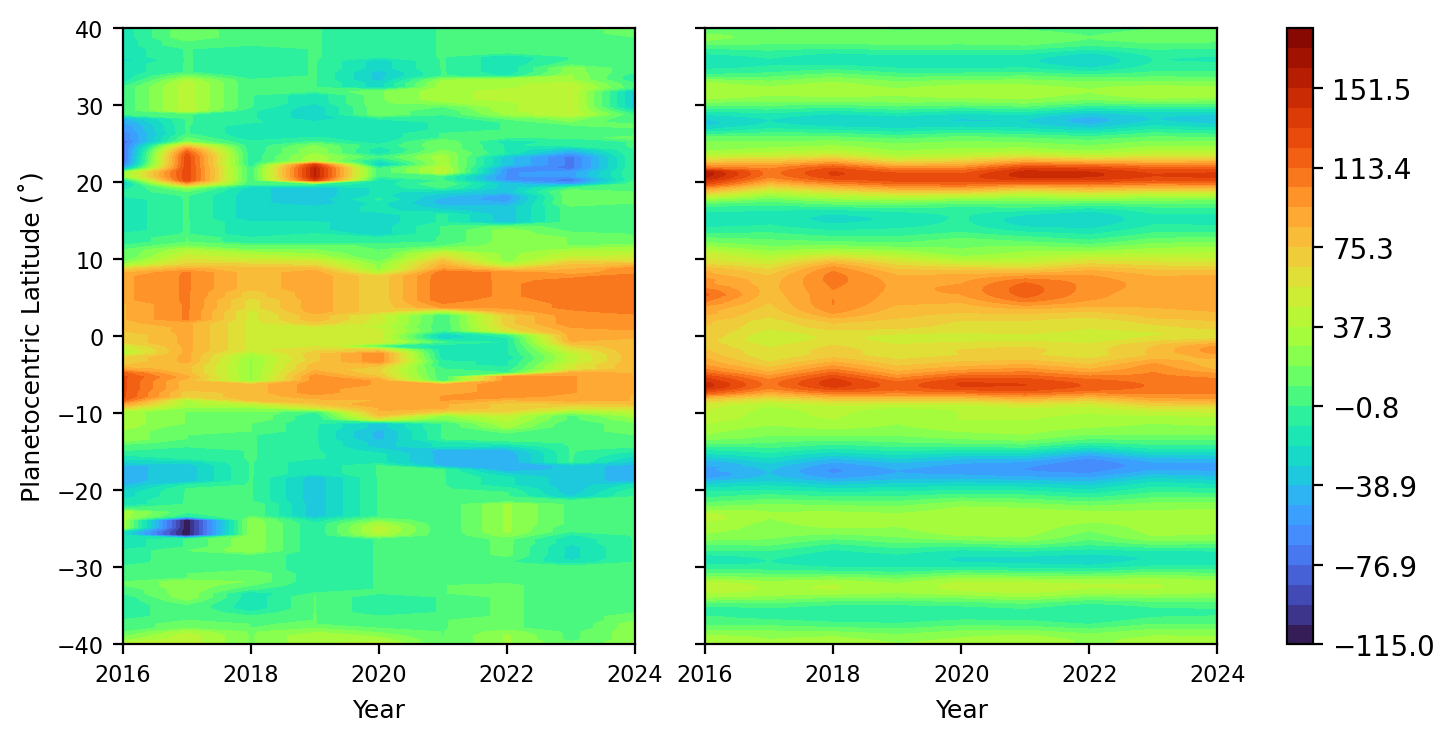

In [60]:
%matplotlib inline
fig = plt.figure(figsize=(7, 4), dpi=200)
cmap = 'turbo'
ylim = 40
gs = GridSpec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.05],  # last column = colorbar
    wspace=0.2
)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

im = ax0.contourf(
    year_arr,
    ZWP_2024['lat_array_used'],
    ZWP_full.T,
    np.linspace(-115, 180, 32),
    cmap=cmap
)

im2 = ax1.contourf(
    year_arr,
    HST_interp_lat_array_cent,
    HST_homo_dataframe.T,
    np.linspace(-115, 180, 32),
    cmap=cmap
)

ax0.set_ylabel('Planetocentric Latitude (˚)', fontsize=9)
ax0.set_xlabel('Year', fontsize=9)
ax0.set_ylim(-ylim, ylim)
ax1.set_xlabel('Year', fontsize=9)
ax1.set_ylim(-ylim, ylim)

ax1.tick_params(labelleft=False)

ax0.tick_params(axis='both', which='major', labelsize=8)
ax1.tick_params(axis='both', which='major', labelsize=8)

fig.subplots_adjust(
    left=0.10,    # just enough to clear y tick labels
    right=0.95,   # keep colorbar safe
    top=0.92,     # remove top whitespace
    bottom=0.15   # leave room for x labels
)
fig.colorbar(im, cax=cax)
fig.tight_layout()
plt.show()


In [14]:
for i_l, l in enumerate(frame2024["lat_array_used"][i_specific][0, :]):
    print(i_l, l)
# lat_array_used[i_specific][0, :].shape

0 -90.0
1 -89.49860724233983
2 -88.99721448467966
3 -88.4958217270195
4 -87.99442896935933
5 -87.49303621169916
6 -86.991643454039
7 -86.49025069637884
8 -85.98885793871867
9 -85.4874651810585
10 -84.98607242339833
11 -84.48467966573816
12 -83.983286908078
13 -83.48189415041783
14 -82.98050139275766
15 -82.47910863509749
16 -81.97771587743733
17 -81.47632311977716
18 -80.974930362117
19 -80.47353760445682
20 -79.97214484679665
21 -79.4707520891365
22 -78.96935933147633
23 -78.46796657381616
24 -77.96657381615599
25 -77.46518105849583
26 -76.96378830083566
27 -76.46239554317549
28 -75.96100278551532
29 -75.45961002785515
30 -74.95821727019498
31 -74.45682451253482
32 -73.95543175487465
33 -73.45403899721448
34 -72.95264623955433
35 -72.45125348189416
36 -71.94986072423399
37 -71.44846796657382
38 -70.94707520891365
39 -70.44568245125348
40 -69.94428969359332
41 -69.44289693593315
42 -68.94150417827298
43 -68.44011142061282
44 -67.93871866295265
45 -67.43732590529248
46 -66.9359331476323

2016 -24.98568908368091 -8.331928586654188
2016 0.0034919562663979775 16.701189373226473
2016 83.60611248544905 100.33440799075635
2016 117.05190585896943 133.7760766085834
2016 33.40936265898574 33.40936265898574
2016 0.0 -0.0
2017 0.0 -0.0
2017 52.66149722713734 52.66149722713734
2017 105.44587522325453 105.44587522325453
2017 79.12738326434207 79.12738326434207
2017 17.553832409045775 17.553832409045775
2017 -8.755392077810322 -8.755392077810322
2018 -8.775315111418287 -26.277433578473904
2018 43.87578284799013 43.87578284799013
2018 70.27346884861879 87.84183606077349
2018 70.25206674052096 87.8150834256512
2018 17.54672566742986 17.54672566742986
2018 0.0 -0.0
2019 -9.091052622354622 -27.232295158594766
2019 36.38239426209068 36.38239426209068
2019 82.00663502281816 100.21654550658855
2019 91.04829722311712 109.26071809835724
2019 -9.087658683232478 -9.087658683232478
2019 -0.015319604113813057 -18.151064560813676
2020 -16.928242864494635 -33.84132071335097
2020 0.0017338924471204

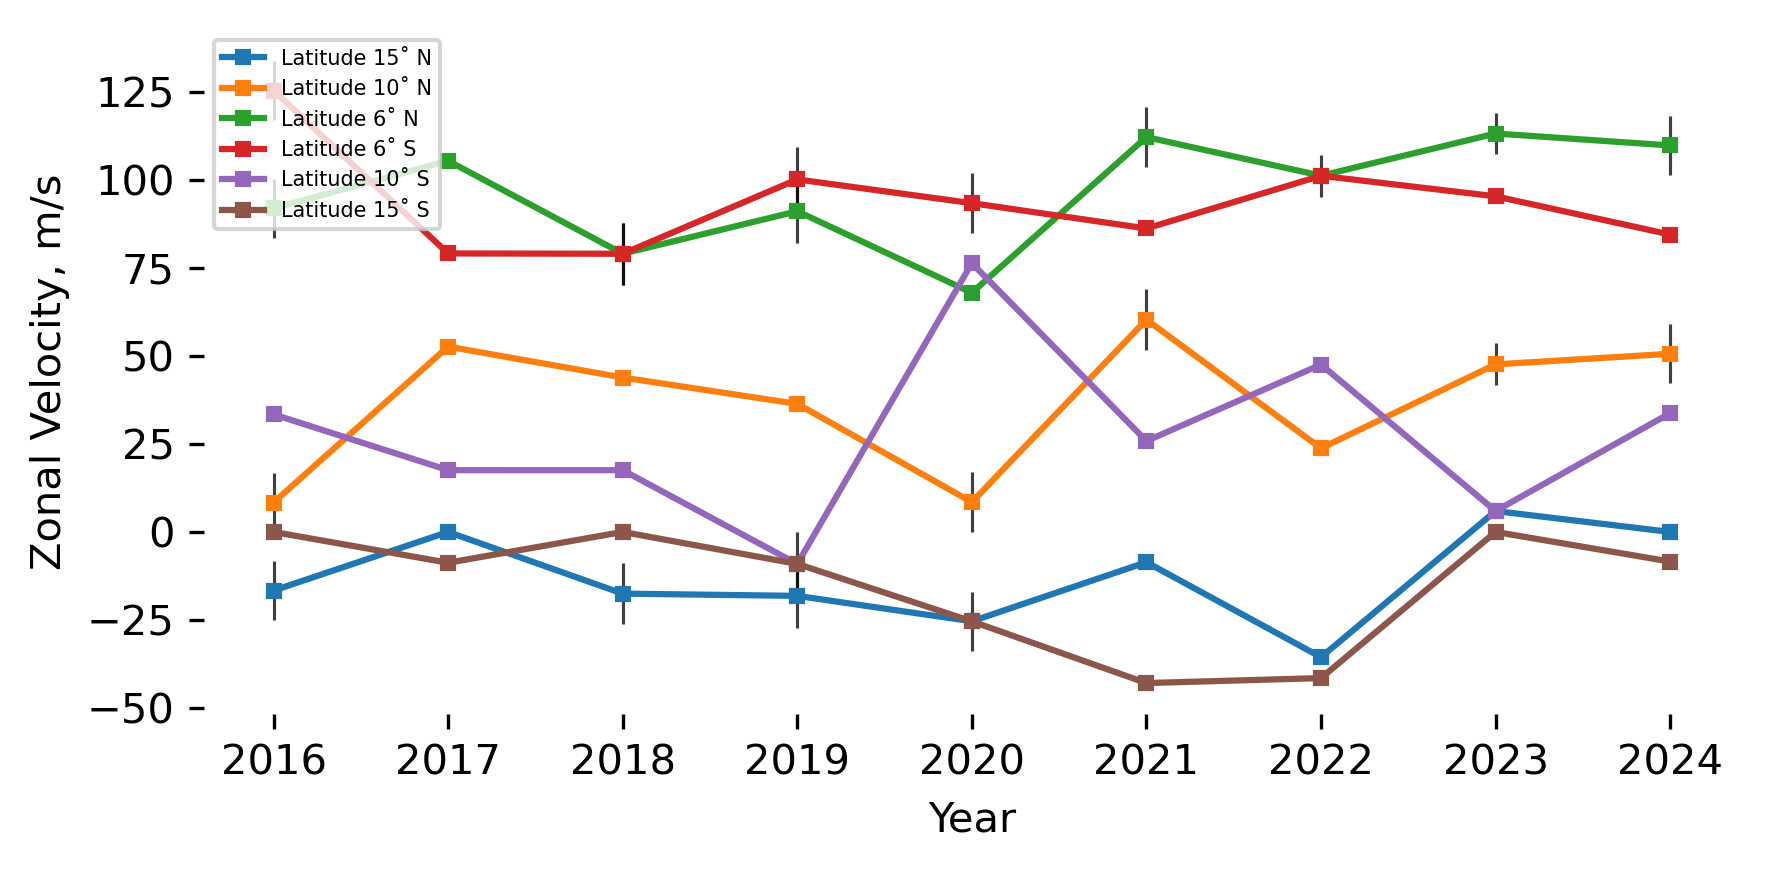

In [15]:
%matplotlib inline

lats_of_interest = np.array([209,200,192,167,159,150])

plt.figure(figsize=(6,3), dpi=300)


for i_t, t in enumerate(year_arr):
    for i_z, z in enumerate(lats_of_interest):
        plt.vlines(t, ZWP_full.T[z, i_t] - ZWP_full_errors.T[z, i_t], 
                   ZWP_full.T[z, i_t] + ZWP_full_errors.T[z, i_t], 
                   colors='k', alpha=0.75, lw=0.75)
        print(t, ZWP_full.T[z, i_t] - ZWP_full_errors.T[z, i_t], ZWP_full.T[z, i_t] + ZWP_full_errors.T[z, i_t])

# lats_of_interest are indices of the relevant latitudes. Created using 
plt.plot(year_arr , ZWP_full.T[209, :], marker='s', ms=3, label='Latitude 15˚ N')
plt.plot(year_arr , ZWP_full.T[200, :], marker='s', ms=3, label='Latitude 10˚ N')
plt.plot(year_arr , ZWP_full.T[192, :], marker='s', ms=3, label='Latitude 6˚ N')
plt.plot(year_arr , ZWP_full.T[167, :], marker='s', ms=3, label='Latitude 6˚ S')
plt.plot(year_arr , ZWP_full.T[159, :], marker='s', ms=3, label='Latitude 10˚ S')
plt.plot(year_arr , ZWP_full.T[150, :], marker='s', ms=3, label='Latitude 15˚ S') 

plt.legend(loc='upper left', fontsize=5)
plt.xlabel('Year'), plt.ylabel('Zonal Velocity, m/s')
plt.gca().set_frame_on(False)
plt.tight_layout()
plt.show()

In [16]:
ZWP_full.T.shape, ZWP_full.T[0, :].shape, ZWP_full.T[:, 0].shape, ZWP_full_errors.T[0, :].shape, ZWP_full_errors.T[:, 0].shape

((360, 9), (9,), (360,), (9,), (360,))

In [17]:
for l in range(len(ZWP_2024['lat_array_used'])):
    print(l, ZWP_2024['lat_array_used'][l])

0 -90.0
1 -89.49860724233983
2 -88.99721448467966
3 -88.4958217270195
4 -87.99442896935933
5 -87.49303621169916
6 -86.991643454039
7 -86.49025069637884
8 -85.98885793871867
9 -85.4874651810585
10 -84.98607242339833
11 -84.48467966573816
12 -83.983286908078
13 -83.48189415041783
14 -82.98050139275766
15 -82.47910863509749
16 -81.97771587743733
17 -81.47632311977716
18 -80.974930362117
19 -80.47353760445682
20 -79.97214484679665
21 -79.4707520891365
22 -78.96935933147633
23 -78.46796657381616
24 -77.96657381615599
25 -77.46518105849583
26 -76.96378830083566
27 -76.46239554317549
28 -75.96100278551532
29 -75.45961002785515
30 -74.95821727019498
31 -74.45682451253482
32 -73.95543175487465
33 -73.45403899721448
34 -72.95264623955433
35 -72.45125348189416
36 -71.94986072423399
37 -71.44846796657382
38 -70.94707520891365
39 -70.44568245125348
40 -69.94428969359332
41 -69.44289693593315
42 -68.94150417827298
43 -68.44011142061282
44 -67.93871866295265
45 -67.43732590529248
46 -66.9359331476323

In [18]:
for l in range(len(centric_lat_HST)):
    print(l, centric_lat_HST[l])

0 -90.0
1 -89.88564373467395
2 -89.77128768374604
3 -89.65693206160951
4 -89.54257708264743
5 -89.42822296122782
6 -89.31386991169866
7 -89.19951814838272
8 -89.08516788557276
9 -88.9708193375263
10 -88.8564727184607
11 -88.74212824254809
12 -88.62778612391051
13 -88.51344657661474
14 -88.39910981466724
15 -88.28477605200946
16 -88.17044550251241
17 -88.05611837997196
18 -87.94179489810384
19 -87.82747527053843
20 -87.71315971081602
21 -87.59884843238171
22 -87.48454164858036
23 -87.37023957265181
24 -87.25594241772573
25 -87.14165039681683
26 -87.0273637228197
27 -86.91308260850398
28 -86.79880726650948
29 -86.68453790934109
30 -86.57027474936397
31 -86.45601799879854
32 -86.34176786971564
33 -86.22752457403153
34 -86.11328832350308
35 -85.99905932972285
36 -85.88483780411411
37 -85.77062395792613
38 -85.65641800222913
39 -85.54222014790956
40 -85.4280306056652
41 -85.31384958600029
42 -85.19967729922067
43 -85.0855139554291
44 -84.9713597645202
45 -84.857214936176
46 -84.743079679860

In [19]:
# IR_dataframe = []
# for i, iy in enumerate(year_arr):
#     output_path = '/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/' + str(year_arr[i]) + '/'
#     output_file_list = glob.glob(output_path + '*.npz')
#     IR_dataframe.append(generateArrays(output_file_list=output_file_list))

# HST_homo_dataframe_mainfile = np.load('OPAL/HST_homo_dataframe.npz')

# HST_homo_dataframe = HST_homo_dataframe_mainfile['HST_homo_dataframe'][0, ...]
# HST_interp_lat_array = HST_homo_dataframe_mainfile['HST_interp_lat_array'][0, ...]
# HST_interp_lat_array_cent = HST_homo_dataframe_mainfile['HST_interp_lat_array_cent'][0, ...]

# opal_2015        = pd.read_excel('OPAL/Simon+2015_ZWP_HST.xlsx') # with only LAT and FMZW
# opal_2016        = pd.read_excel('OPAL/ZWP_j2016.xlsx')
# opal_2017        = pd.read_excel('OPAL/2017_631.xlsx')
# opal_2018        = pd.read_excel('OPAL/2018_631.xlsx')
# opal_2019        = pd.read_excel('OPAL/2019_631.xlsx')
# opal_2020        = pd.read_excel('OPAL/2020_631.xlsx')
# opal_2021        = pd.read_excel('OPAL/2021_631.xlsx')
# opal_2022        = pd.read_excel('OPAL/2022_631.xlsx')
# opal_2024b       = pd.read_excel('OPAL/2024b_631.xlsx')
# opal_nov_2024_df = pd.read_excel('OPAL/2024nov_jup_502.xlsx')

# HST_ZWP_list = [opal_2016 ,opal_2017 ,opal_2018 ,opal_2019 ,opal_2020 ,opal_2021 ,opal_2022 ,opal_2024b,opal_nov_2024_df]


9
1.114575000000002
0.8972029697418281
0.44860148487091406
[-11.11442006 -12.43672632 -16.93884057 -11.64610352  -7.63615236
 -14.31423599 -22.48932439  -8.95606251  -8.66057321]


/var/folders/xh/s9lkw5113q98j632zllsplyr0000gq/T/ipykernel_52689/1014067905.py:107: ComplexWarning: Casting complex values to real discards the imaginary part
  FFT_field[:, f] = np.fft.fft(dataset[:, f]) / time_signal_length__per_lat


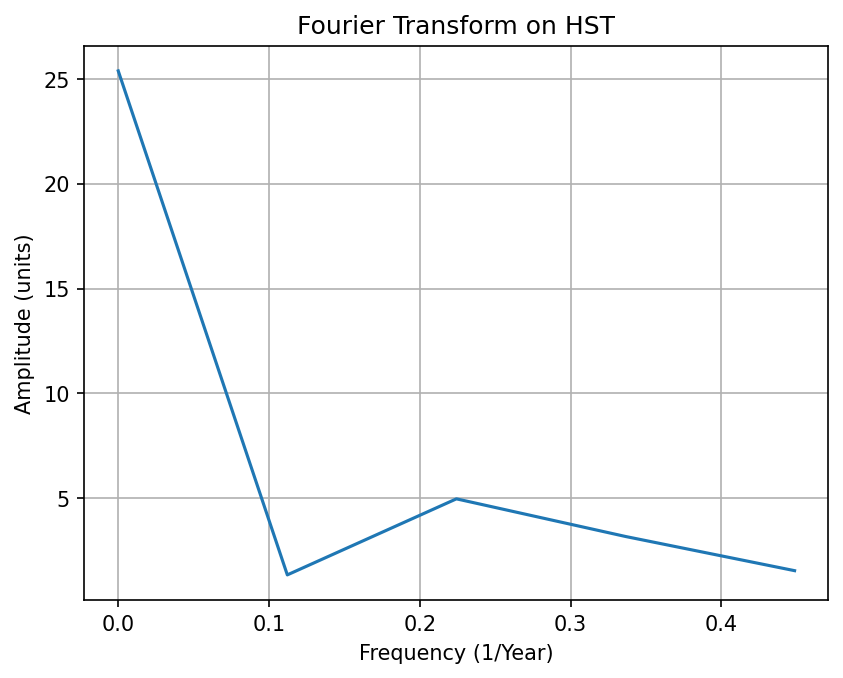

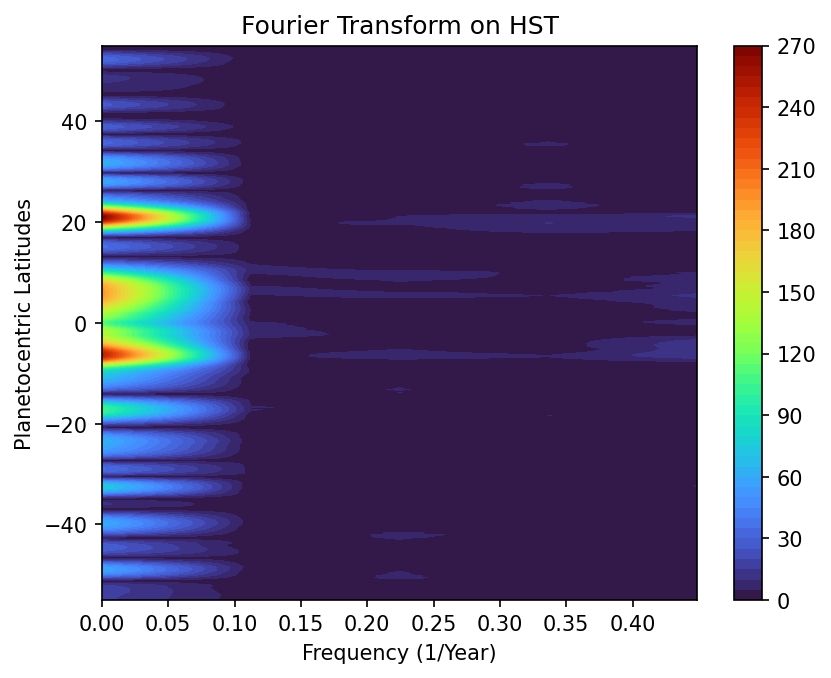

In [20]:
year_arr_hst = np.array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2024.0833, 2024.9166])

# for HST dataset:
FFT_field, Fv_field, FTs, Iv, Fv = getFFTfields(year_arr_hst, HST_homo_dataframe)

%matplotlib inline
# Plot Fourier Transform
plt.figure(dpi=150)
plt.plot(Fv, 2 * np.abs(FTs[Iv]))
plt.grid(True)
plt.title('Fourier Transform on HST')
plt.xlabel('Frequency (1/Year)')
# plt.xlabel('Periodicity')
plt.ylabel('Amplitude (units)')


# Plot Fourier Transform
plt.figure(dpi=150)
plt.contourf(Fv_field[:, -1], HST_interp_lat_array_cent, 2 * np.abs(FFT_field[:5, :].T), levels=64, cmap='turbo') 
plt.title('Fourier Transform on HST')
plt.xlabel('Frequency (1/Year)')
plt.colorbar()
plt.ylabel('Planetocentric Latitudes')
plt.ylim(-55, 55)
plt.show()

9
1.0
1.0
0.5
[33.40936266 17.55383241 17.54672567 -9.08765868 76.37063253 25.84311717
 47.55172329  5.94848335 33.74584922]


/var/folders/xh/s9lkw5113q98j632zllsplyr0000gq/T/ipykernel_52689/1014067905.py:107: ComplexWarning: Casting complex values to real discards the imaginary part
  FFT_field[:, f] = np.fft.fft(dataset[:, f]) / time_signal_length__per_lat


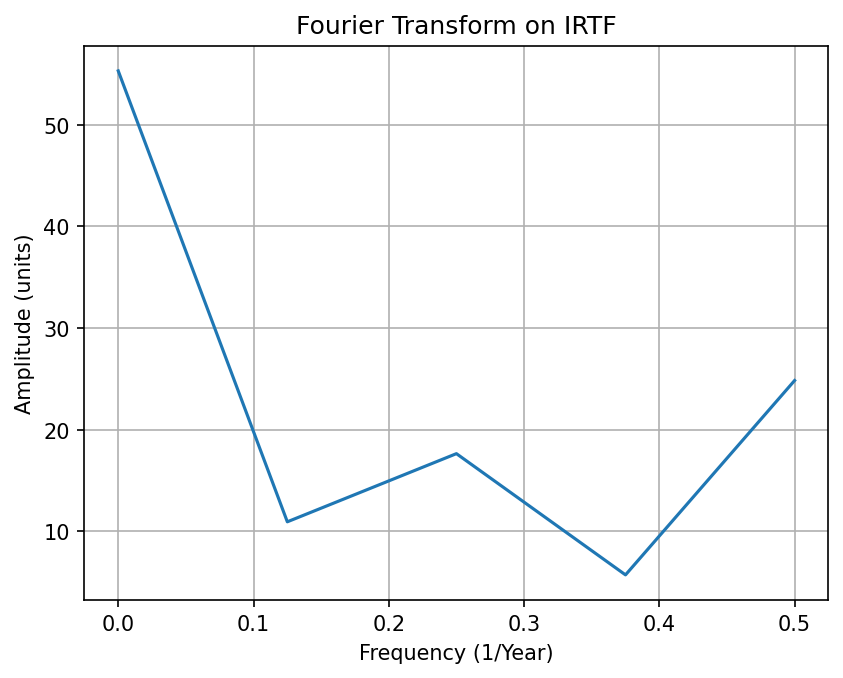

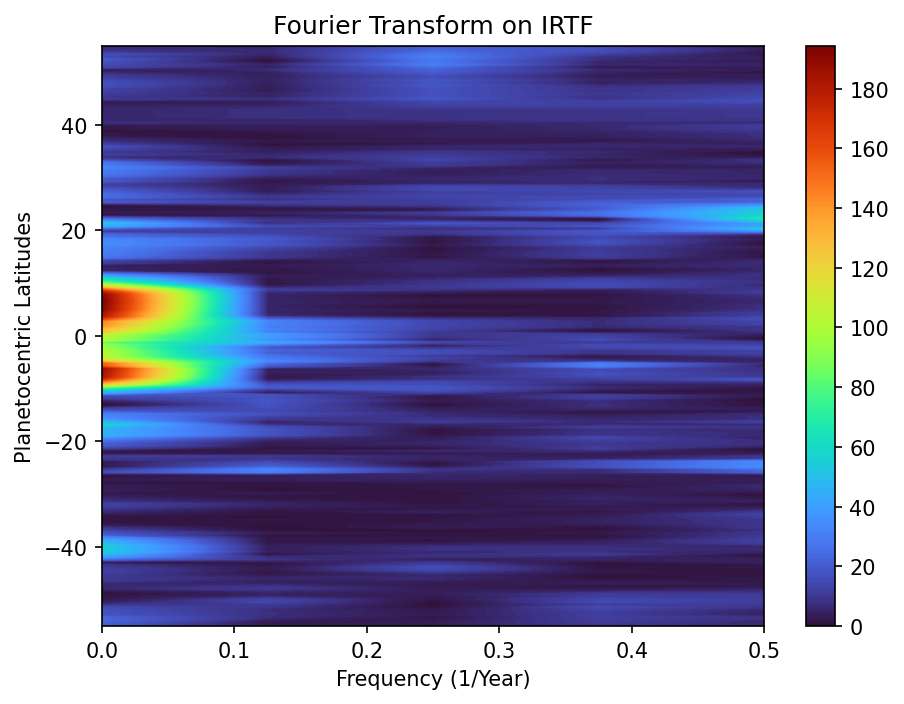

In [21]:

# for IRTF dataset:
FFT_field, Fv_field, FTs, Iv, Fv = getFFTfields(year_arr, ZWP_full, test_lat=159)

%matplotlib inline
# Plot Fourier Transform
plt.figure(dpi=150)
plt.plot(Fv, 2 * np.abs(FTs[Iv]))
plt.grid(True)
plt.title('Fourier Transform on IRTF')
plt.xlabel('Frequency (1/Year)')
# plt.xlabel('Periodicity')
plt.ylabel('Amplitude (units)')


# Plot Fourier Transform
plt.figure(dpi=150)
plt.contourf(Fv_field[:, -1], ZWP_2024['lat_array_used'], 2 * np.abs(FFT_field[:5, :].T), levels=256, cmap='turbo') 
plt.title('Fourier Transform on IRTF')
plt.xlabel('Frequency (1/Year)')
plt.colorbar()
plt.ylabel('Planetocentric Latitudes')
plt.ylim(-55, 55)
plt.tight_layout()
plt.show()

In [22]:
print(ZWP_full.shape), print(HST_homo_dataframe.shape)

(9, 360)
(9, 1596)


(None, None)

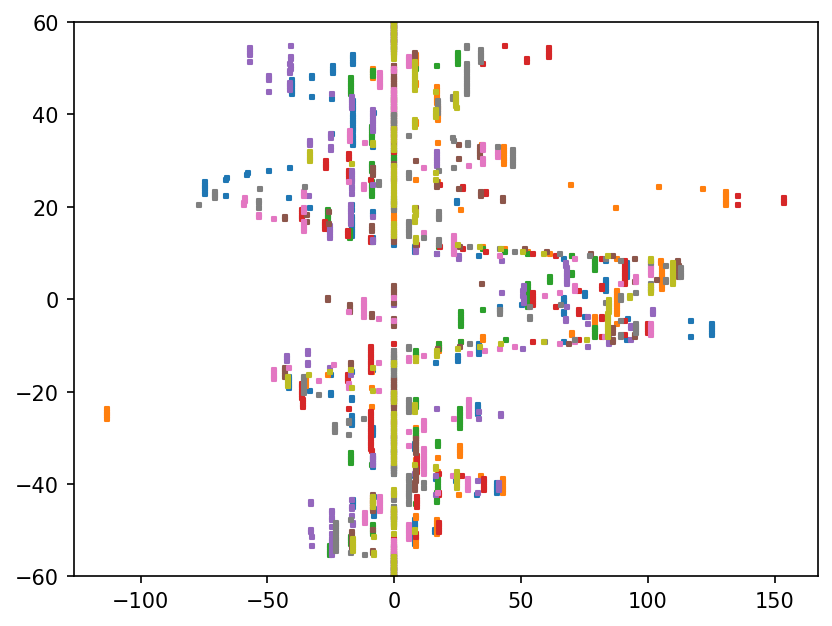

In [23]:
plt.figure(dpi=150)
for iy, y in enumerate(year_arr):
    plt.scatter(ZWP_full[iy, :], ZWP_2024['lat_array_used'], marker='s', s=5)

ylim=60
plt.ylim(-ylim, ylim)
plt.show()

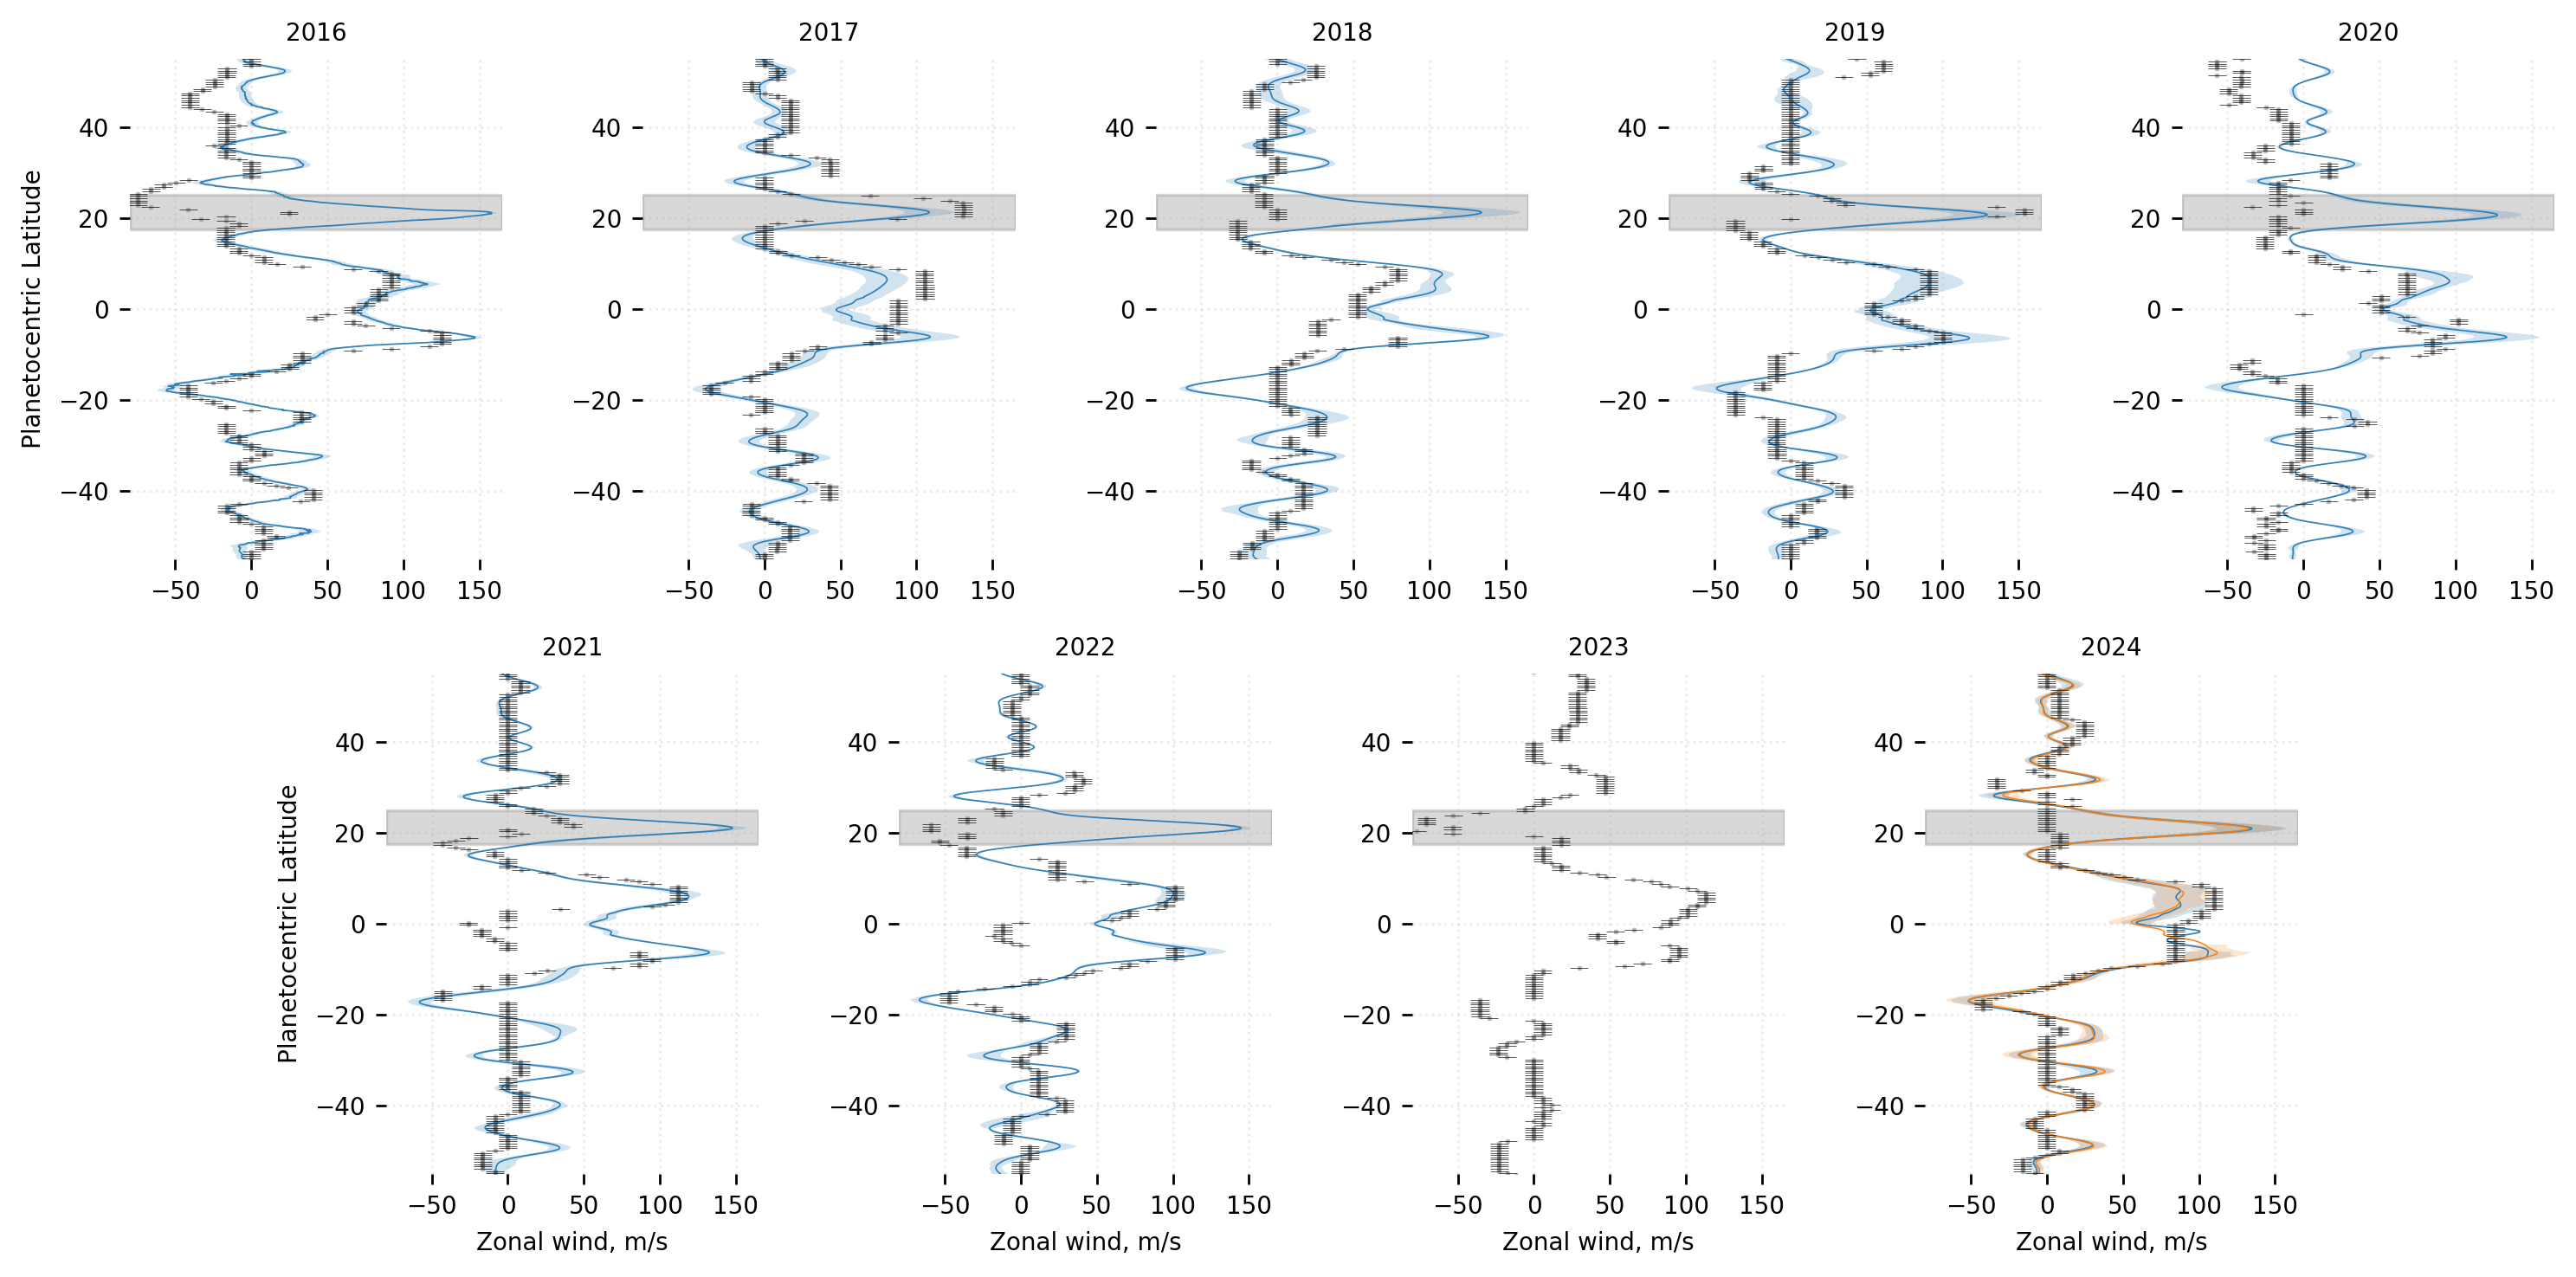

In [24]:
%matplotlib inline
fig = plt.figure(figsize=(12, 6), dpi=250)
gs = GridSpec(2, 10, figure=fig)  # finer grid (10 columns)

axes = []
ylim = 55
xlim_lo, xlim_hi = -80, 165
err_bound = 6.0

# Top row: 5 plots (each spanning 2 columns)
for i in range(5):
    ax = fig.add_subplot(gs[0, 2*i:2*i+2])
    ax.set_title(str(year_arr[i]), fontsize=8)
    ax.fill_betweenx(np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[i]['LAT'])), 
                     HST_ZWP_list[i]['FMZW'] - HST_ZWP_list[i]['ERROR'], HST_ZWP_list[i]['FMZW'] + HST_ZWP_list[i]['ERROR'], alpha=0.2) 
    ax.plot(HST_ZWP_list[i]['FMZW'], np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[i]['LAT'])), 
            lw=0.5, alpha=0.9)
    for z in range(len(ZWP_full[i, :])):
        ax.hlines(ZWP_2024['lat_array_used'][z], ZWP_full[i, z]-err_bound, ZWP_full[i, z]+err_bound, colors='k', alpha=0.75, lw=0.25)
        # if (ZWP_full_errors[i, z] == 0):
        #     ax.hlines(ZWP_2024['lat_array_used'][z], min(ZWP_full[i, z]-ZWP_full_errors[i, z], ZWP_full[i, z]-10.0), max(ZWP_full[i, z]+ZWP_full_errors[i, z], ZWP_full[i, z]+10.0), colors='k', alpha=0.75, lw=0.25)
        # else:
        #     ax.hlines(ZWP_2024['lat_array_used'][z], ZWP_full[i, z]-ZWP_full_errors[i, z], ZWP_full[i, z]+ZWP_full_errors[i, z], colors='k', alpha=0.75, lw=0.25)
    ax.scatter(ZWP_full[i, :], ZWP_2024['lat_array_used'], marker='s', color='k', s=0.5, alpha=0.25)
    ax.axhspan(17.5, 25, color='gray', alpha=0.3)
    axes.append(ax)
    ax.set_ylim(-ylim, ylim)
    ax.set_xlim(xlim_lo, xlim_hi)
    ax.set_frame_on(False)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.grid(True, ls=':', alpha=0.25)
    if i==0:
        ax.set_ylabel('Planetocentric Latitude', fontsize=8)

# Bottom row: 4 plots (each spanning 2 columns), centered
for i in range(4):
    j = i + 5
    ax = fig.add_subplot(gs[1, 1+2*i:1+2*i+2])
    ax.set_title(str(year_arr[j]), fontsize=8)
    if j!=7: # also handles j==8...
        ax.fill_betweenx(np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[j]['LAT'])), 
                         HST_ZWP_list[j]['FMZW'] - HST_ZWP_list[j]['ERROR'], HST_ZWP_list[j]['FMZW'] + HST_ZWP_list[j]['ERROR'], alpha=0.2) 
        ax.plot(HST_ZWP_list[j]['FMZW'], np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[j]['LAT'])), 
                lw=0.5, alpha=0.9)
    if j==8:
        ax.fill_betweenx(np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[j-1]['LAT'])), 
                         HST_ZWP_list[j-1]['FMZW'] - HST_ZWP_list[j-1]['ERROR'], HST_ZWP_list[j-1]['FMZW'] + HST_ZWP_list[j-1]['ERROR'], alpha=0.2) 
        ax.plot(HST_ZWP_list[j-1]['FMZW'], np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[j-1]['LAT'])), 
                lw=0.5, alpha=0.9)
    for z in range(len(ZWP_full[i, :])):
        ax.hlines(ZWP_2024['lat_array_used'][z], ZWP_full[j, z]-err_bound, ZWP_full[j, z]+err_bound, colors='k', alpha=0.75, lw=0.25)
        # if (ZWP_full_errors[j, z] == 0):
        #     ax.hlines(ZWP_2024['lat_array_used'][z], min(ZWP_full[j, z]-ZWP_full_errors[j, z], ZWP_full[j, z]-10.0), max(ZWP_full[j, z]+ZWP_full_errors[j, z], ZWP_full[j, z]+10.0), colors='k', alpha=0.75, lw=0.25)
        # else:
        #     ax.hlines(ZWP_2024['lat_array_used'][z], ZWP_full[j, z]-ZWP_full_errors[j, z], ZWP_full[j, z]+ZWP_full_errors[j, z], colors='k', alpha=0.75, lw=0.25)
    ax.scatter(ZWP_full[j, :], ZWP_2024['lat_array_used'], marker='s', color='k', s=0.5, alpha=0.25)
    ax.set_ylim(-ylim, ylim)
    ax.set_xlim(xlim_lo, xlim_hi)
    ax.axhspan(17.5, 25, color='gray', alpha=0.3)
    axes.append(ax)
    ax.set_frame_on(False)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.grid(True, ls=':', alpha=0.25)
    ax.set_xlabel('Zonal wind, m/s', fontsize=8)
    if i==0:
        ax.set_ylabel('Planetocentric Latitude', fontsize=8)

plt.tight_layout()
plt.show()

In [25]:
print((ZWP_full_errors[0, :] == 0))
print((ZWP_full_errors[0, :]))

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True False False False False False False False False  True  True
  True  True  True  True  True False False False  True  True  True  True
  True False False False False False  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True False False  True
  True  True  True  True  True  True  True  True  True False False False
 False False False False False False  True  True  True  True  True  True
  True  True  True  True  True  True  True  True Fa

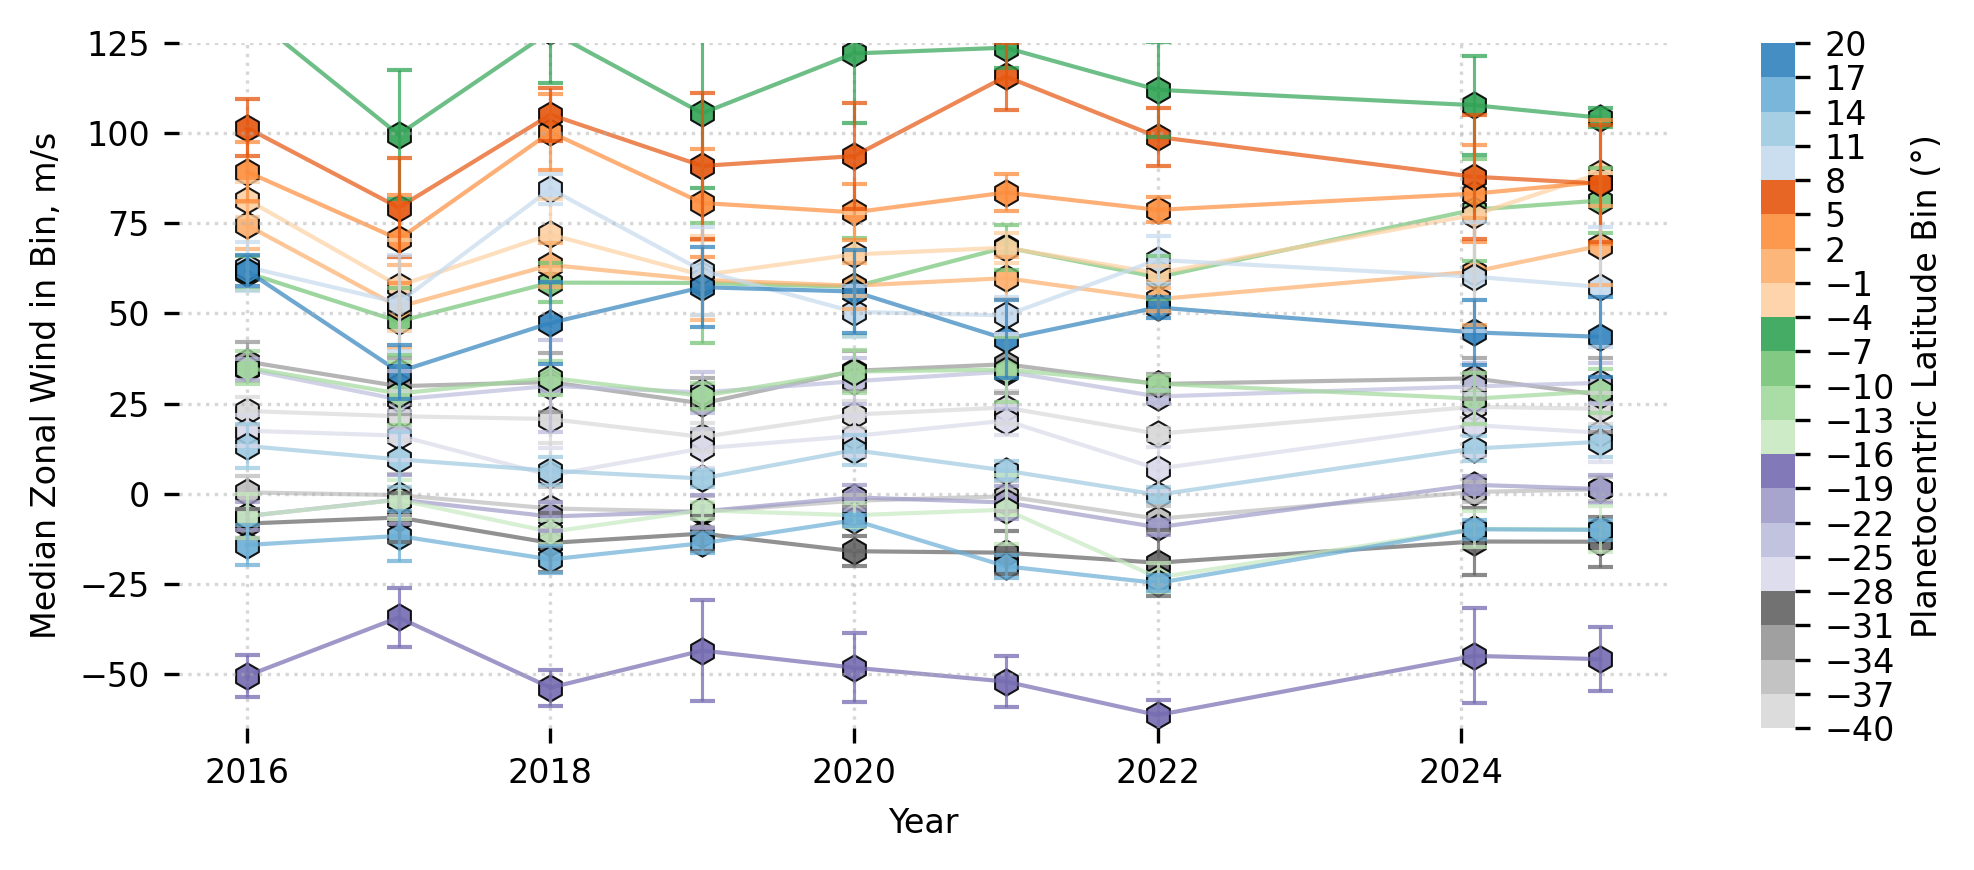

In [26]:
bins_hst = np.arange(-40., 21., 3)
bin_centers = 0.5 * (bins_hst[:-1] + bins_hst[1:])  # Midpoints for coloring
# Create the normalizer and colormap explicitly
cmap_str = 'tab20c_r' #'tab20c_r'
norm = mpl.colors.Normalize(vmin=bins_hst.min(), vmax=bins_hst.max())
cmap = plt.get_cmap(cmap_str)


%matplotlib inline
fig = plt.figure(figsize=(7,3), dpi=300)
ax = fig.add_subplot(111)

color_arr = plt.cm.coolwarm(np.linspace(0, 1, len(bins_hst[:-1])))
hst_each_bin_in_time = np.empty((len(bin_centers), len(year_arr_hst)))
hex_color_arr = np.empty((len(bins_hst[:-1]), 4))
for bh in range(len(bins_hst[:-1])):
    # Compute color explicitly for this bin
    color_test = cmap(norm(bin_centers[bh]))  # RGBA tuple
    hex_color = mcolors.to_hex(color_test)
    hex_color_arr[bh, :] = color_test

    year_vals, wind_vals = [], []  # store for this bin
    for i, iy in enumerate(year_arr_hst):
        zwp_in_cent_i = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[i]['LAT']))
        strt_ind, _ = ZWP_Class.closestIndex2Lat(zwp_in_cent_i, bins_hst[:-1][bh])
        end_ind,  _ = ZWP_Class.closestIndex2Lat(zwp_in_cent_i, bins_hst[1::][bh])
        wind_med = np.median(HST_ZWP_list[i]['FMZW'][strt_ind:end_ind+1])
        lat_med  = np.median(zwp_in_cent_i[strt_ind:end_ind+1])
        year_vals.append(year_arr_hst[i])
        wind_vals.append(wind_med)
        
        err_i = HST_ZWP_list[i]['ERROR'][strt_ind:end_ind+1]
        N = len(err_i)
        # scatter in measurement vs. scatter in median...
        # measurement scatter (typical per-point error)
        # err_scatter = np.sqrt(np.mean(err_i**2)) # RMS of errors
        err_scatter = np.median(err_i) # median of errors
        # uncertainty on the median of the bin
        err_median = 1.253 * err_scatter / np.sqrt(N) # uncertainty on the median

        im1 = ax.scatter(
            year_arr_hst[i],
            wind_med,
            marker='h',
            c=bin_centers[bh],    # use bin center value for color mapping
            cmap=cmap_str,
            vmin=bins_hst.min(),
            vmax=bins_hst.max(),
            s=40,
            alpha=0.9,
            edgecolor='k',
            linewidths=0.5
        )
        
        # (A) Larger vertical bars: scatter of measurements
        ax.errorbar(
            year_arr_hst[i], wind_med, yerr=err_scatter,
            fmt='none', ecolor=hex_color, elinewidth=0.75, alpha=0.75,
            capsize=3, zorder=2, label='Measurement Scatter (RMS)'
        )
        # # (B) Smaller bars: uncertainty on median
        # ax.errorbar(
        #     year_arr_hst[i], wind_med, yerr=err_median,
        #     fmt='none', ecolor='c', elinewidth=1.0, alpha=0.4,
        #     capsize=3, zorder=4, label='Uncertainty on Median'
        # )
    

    # Convert to numpy arrays and sort by year to ensure correct connection order
    year_vals = np.array(year_arr_hst)
    wind_vals = np.array(wind_vals)
    # sort_idx = np.argsort(year_vals)
    # year_vals, wind_vals = year_vals[sort_idx], wind_vals[sort_idx]

    # HST winds in time for each bin center:
    hst_each_bin_in_time[bh, :] = wind_vals

    # Plot line connecting scatter points for this bin
    ax.plot(
        year_vals,
        wind_vals,
        color=hex_color,#plt.cm.tab20c_r(bh / (len(bins_hst[1::]))),
        linewidth=1.0,
        alpha=0.7,
        zorder=1
    )

# Add colorbar
cbar = plt.colorbar(im1, ax=ax)
cbar.set_label("Planetocentric Latitude Bin (°)", fontsize=8)
cbar.set_ticks(bins_hst)
cbar.ax.tick_params(labelsize=8)   # smaller tick label font)
cbar.ax.set_frame_on(False)

plt.xlabel("Year", fontsize=8)
plt.ylabel("Median Zonal Wind in Bin, m/s", fontsize=8)
plt.gca().tick_params('both', labelsize=8)
plt.tight_layout()
plt.gca().set_frame_on(False)
plt.grid(True, ls=':', alpha=0.5)
plt.ylim(-65, 125)
plt.show()

In [27]:
bins_hst, bin_centers

(array([-40., -37., -34., -31., -28., -25., -22., -19., -16., -13., -10.,
         -7.,  -4.,  -1.,   2.,   5.,   8.,  11.,  14.,  17.,  20.]),
 array([-38.5, -35.5, -32.5, -29.5, -26.5, -23.5, -20.5, -17.5, -14.5,
        -11.5,  -8.5,  -5.5,  -2.5,   0.5,   3.5,   6.5,   9.5,  12.5,
         15.5,  18.5]))

In [28]:
print(len(IR_dataframe), IR_dataframe[0].keys())
for i, iy in enumerate(year_arr):
    print('For ', iy, ', there were ', len(IR_dataframe[i]["corr1D_list"]), ' 1D IR wind profiles with shape: ', 
          IR_dataframe[i]["corr1D_list"][0][0, :].shape,
          ' and ', IR_dataframe[i]["corr_slide_list"][0][0, ...].shape, ' slides for the window correlations...')


9 dict_keys(['corr1D_list', 'corr1D_err_list', 'corr1D_fwhm_list', 'corr_slide_list', 'corr_slide_err_list', 'corr_slide_fwhm_list', 'lat_array_used', 'long_array_use', 'margin_applied_in_func_shifted', 'date_list', 'delta_t_list', 'crit_lat_list', 'pair_name_list'])
For  2016 , there were  11  1D IR wind profiles with shape:  (360,)  and  (360, 96)  slides for the window correlations...
For  2017 , there were  10  1D IR wind profiles with shape:  (360,)  and  (360, 116)  slides for the window correlations...
For  2018 , there were  6  1D IR wind profiles with shape:  (360,)  and  (360, 93)  slides for the window correlations...
For  2019 , there were  17  1D IR wind profiles with shape:  (360,)  and  (360, 103)  slides for the window correlations...
For  2020 , there were  12  1D IR wind profiles with shape:  (180,)  and  (180, 111)  slides for the window correlations...
For  2021 , there were  16  1D IR wind profiles with shape:  (180,)  and  (180, 104)  slides for the window correla

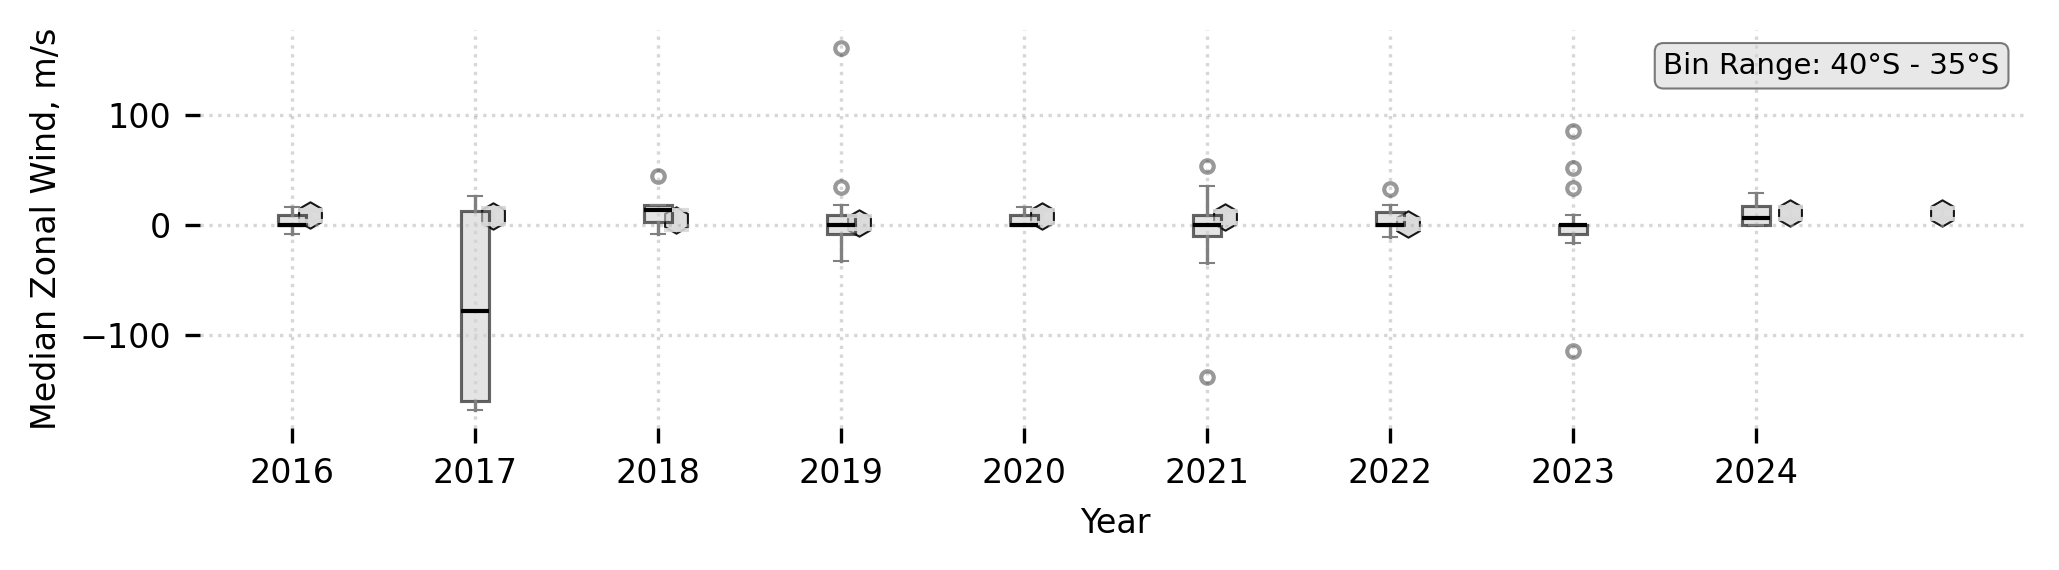

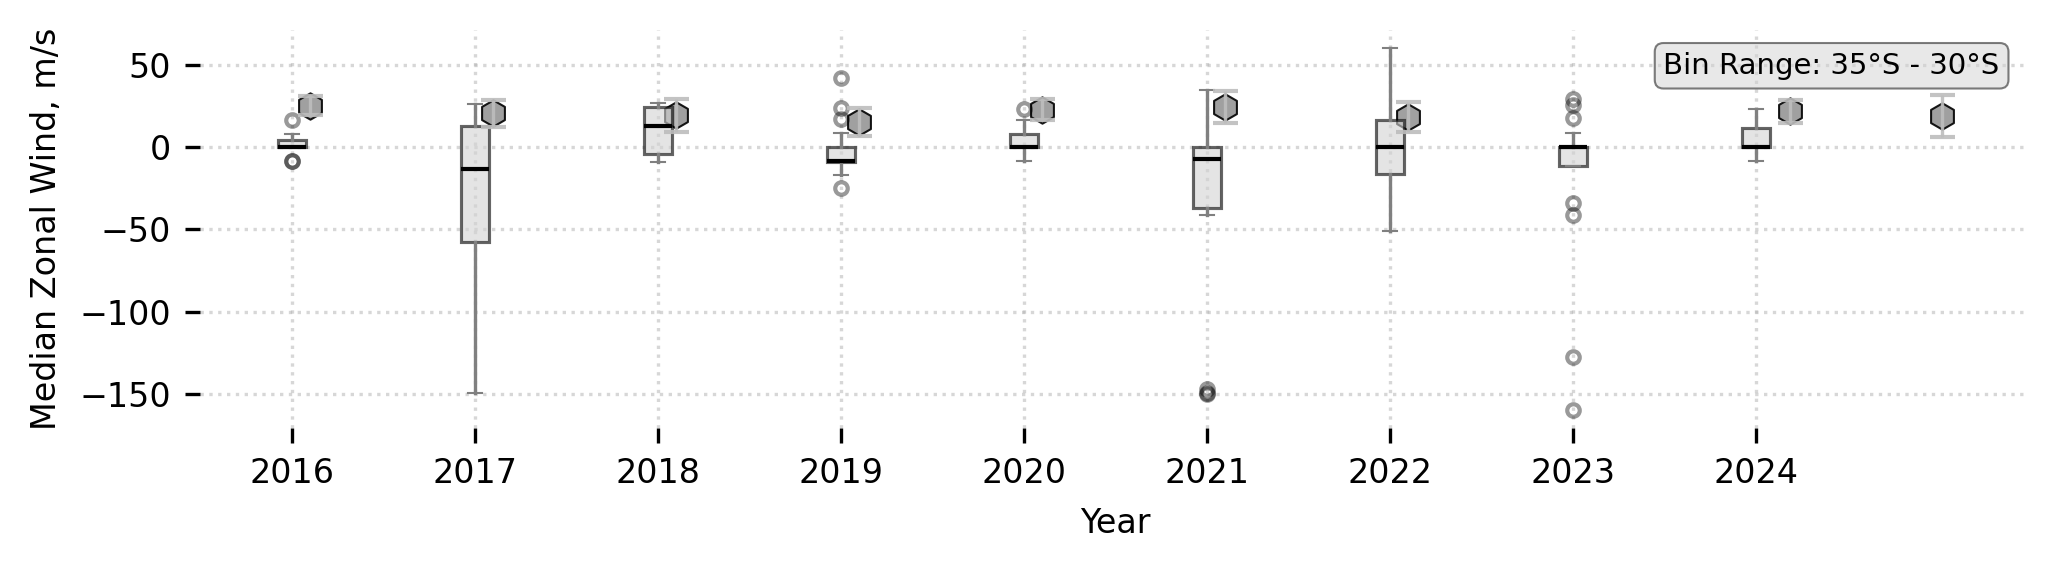

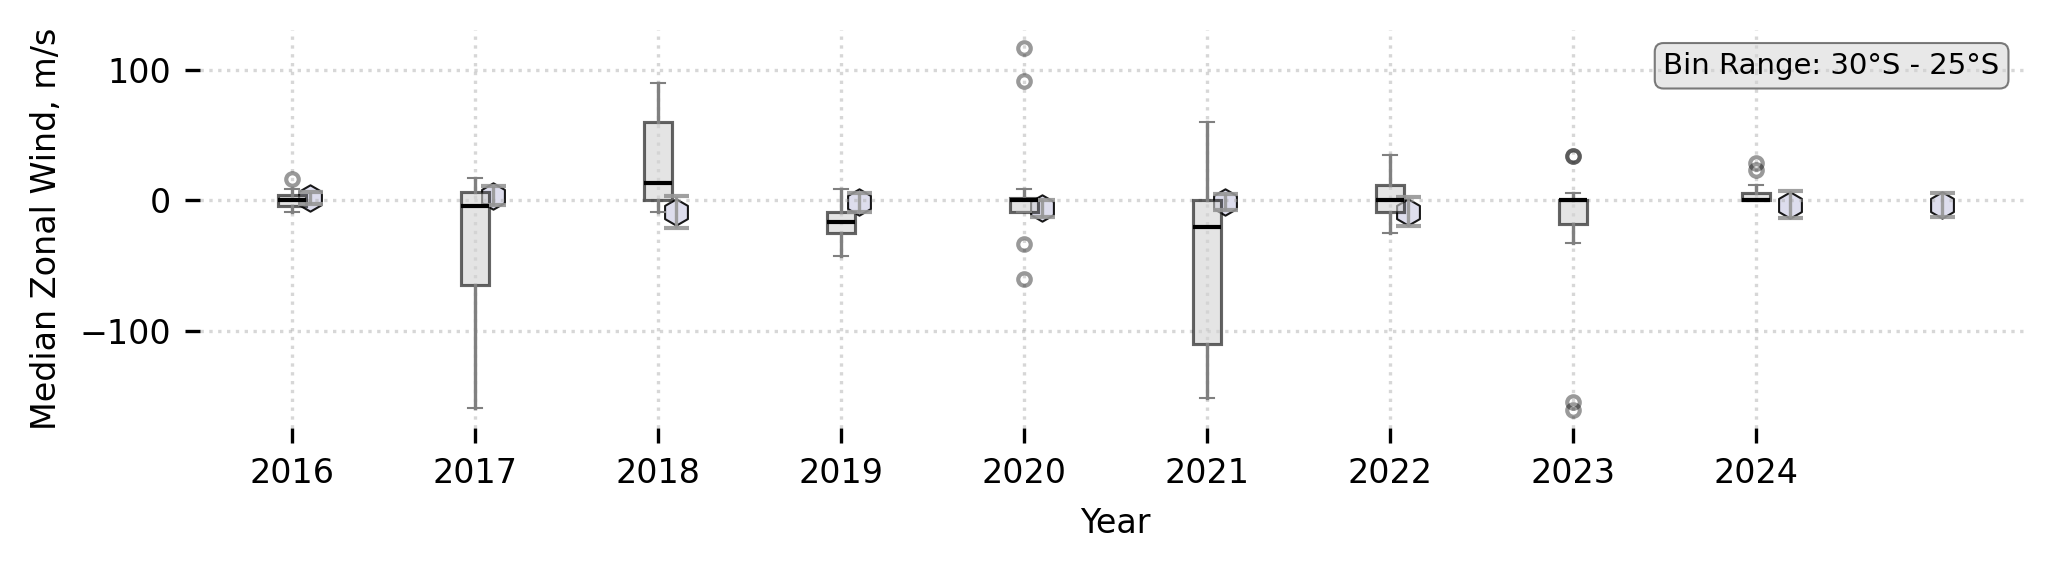

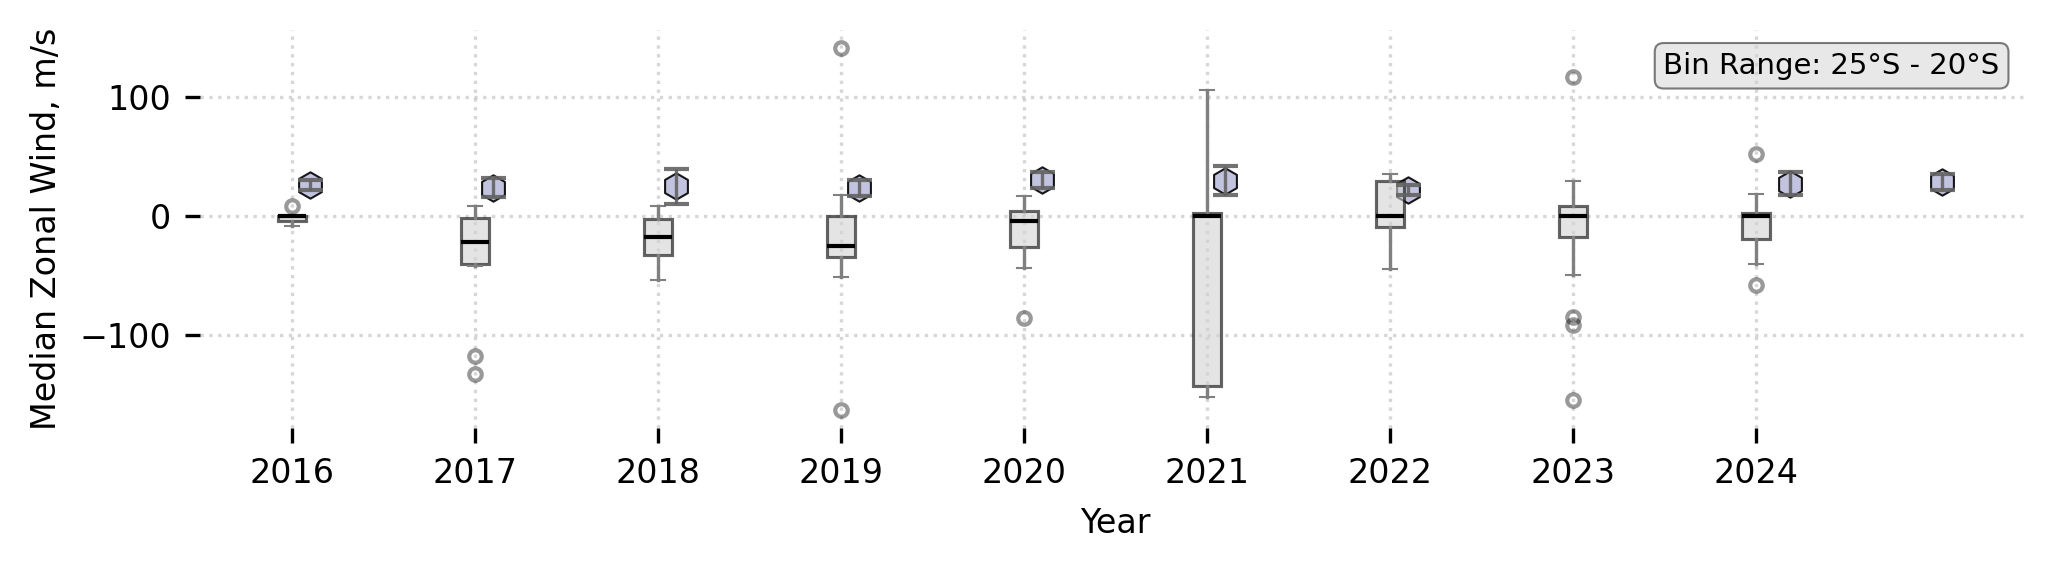

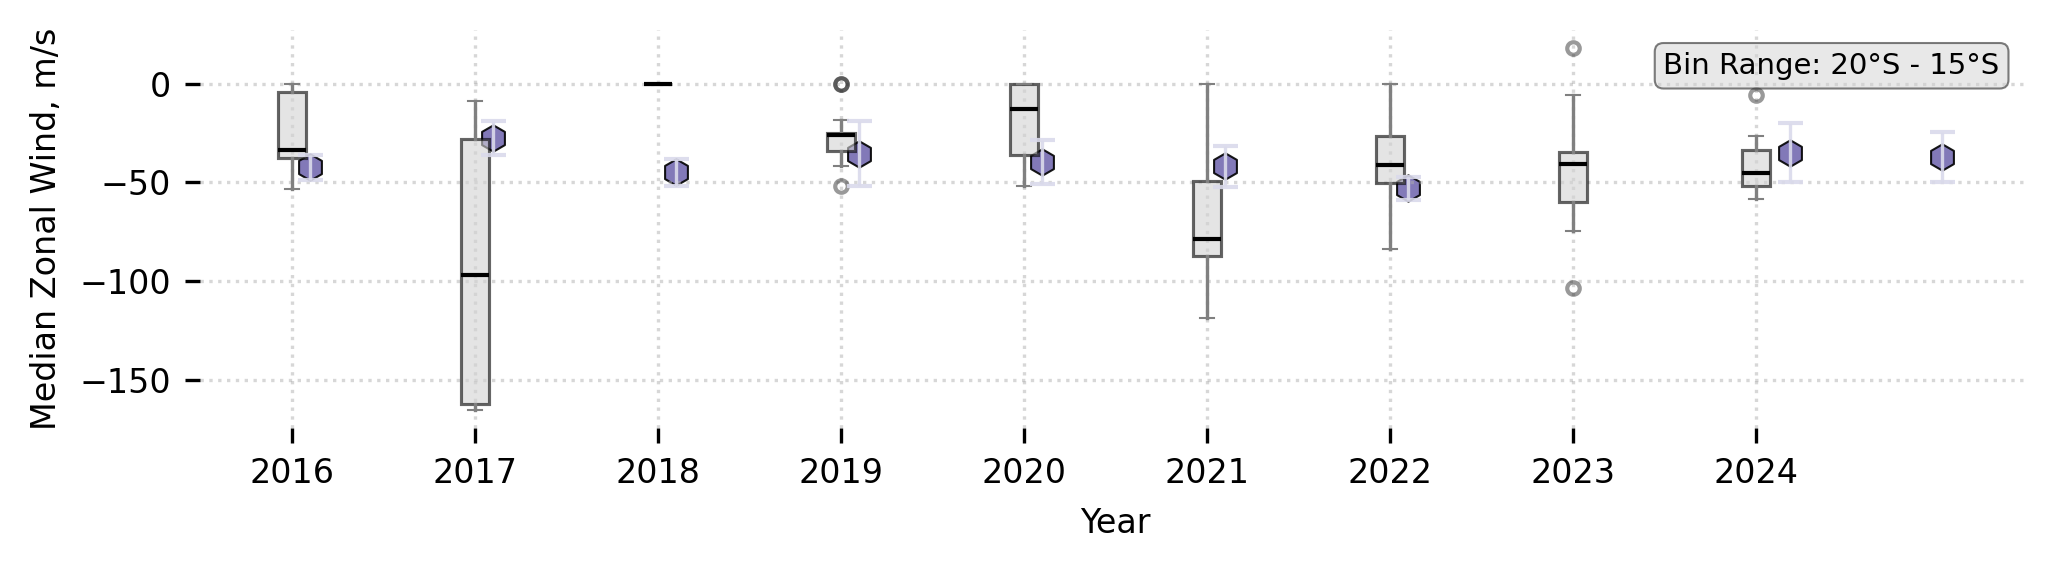

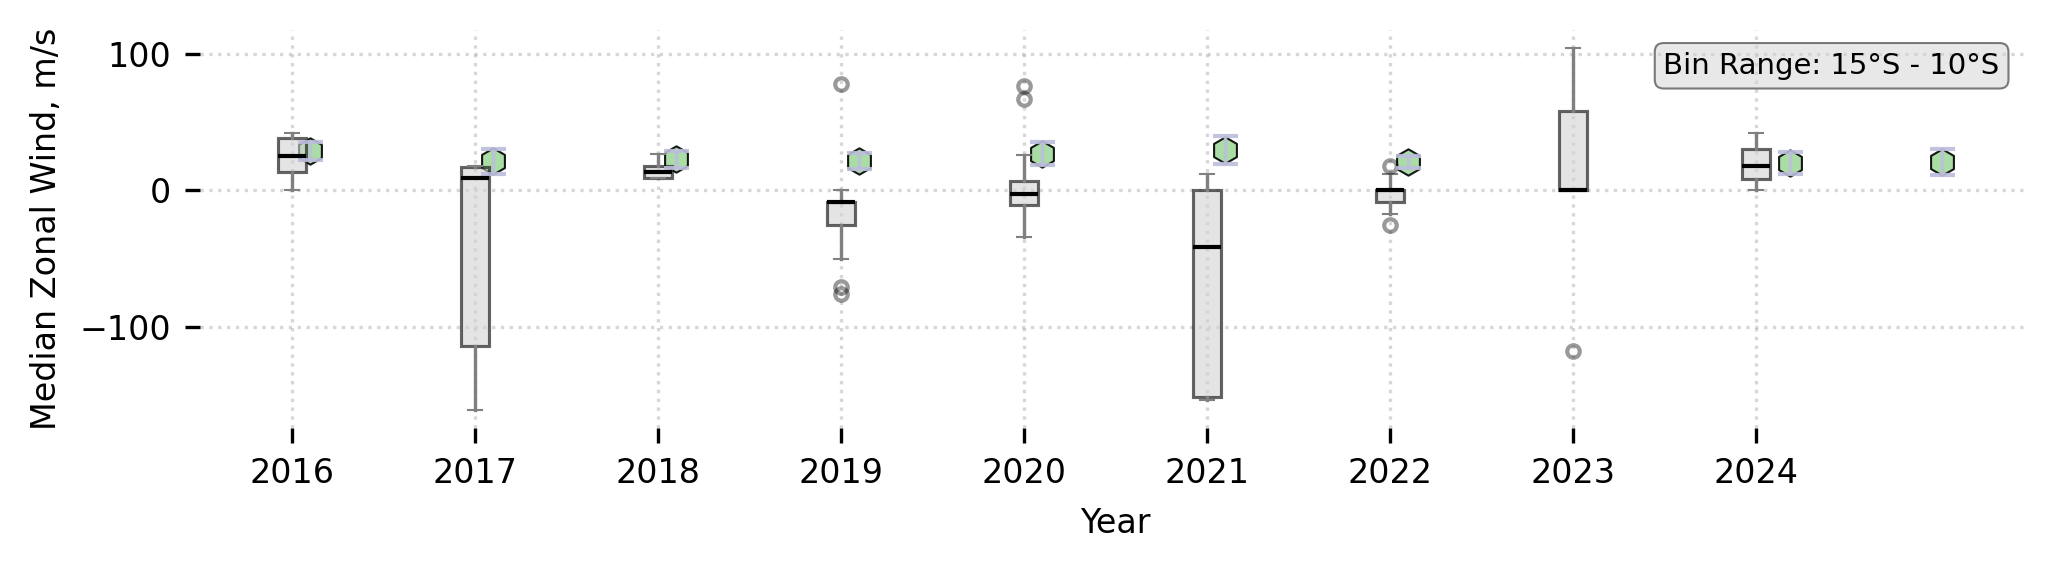

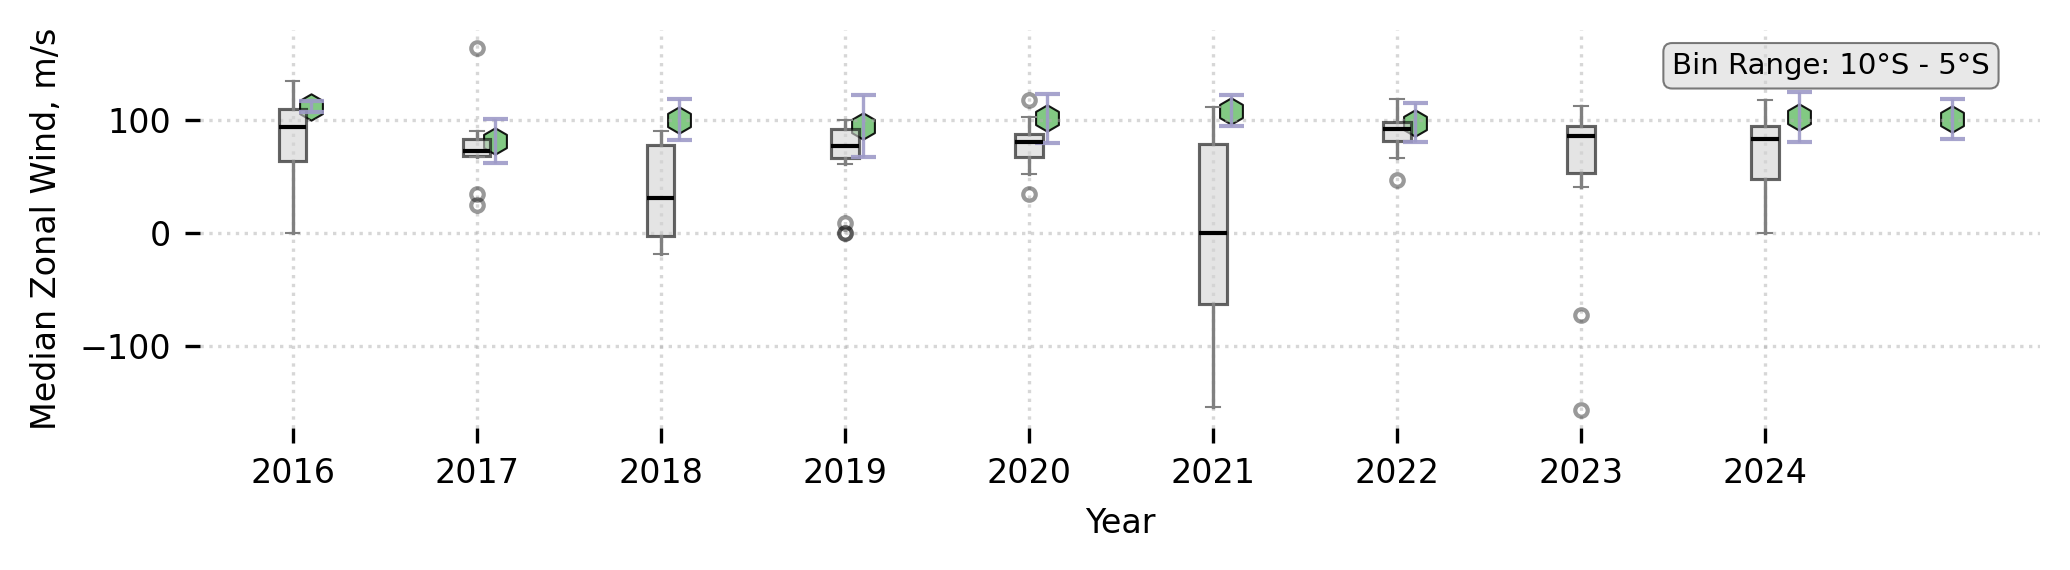

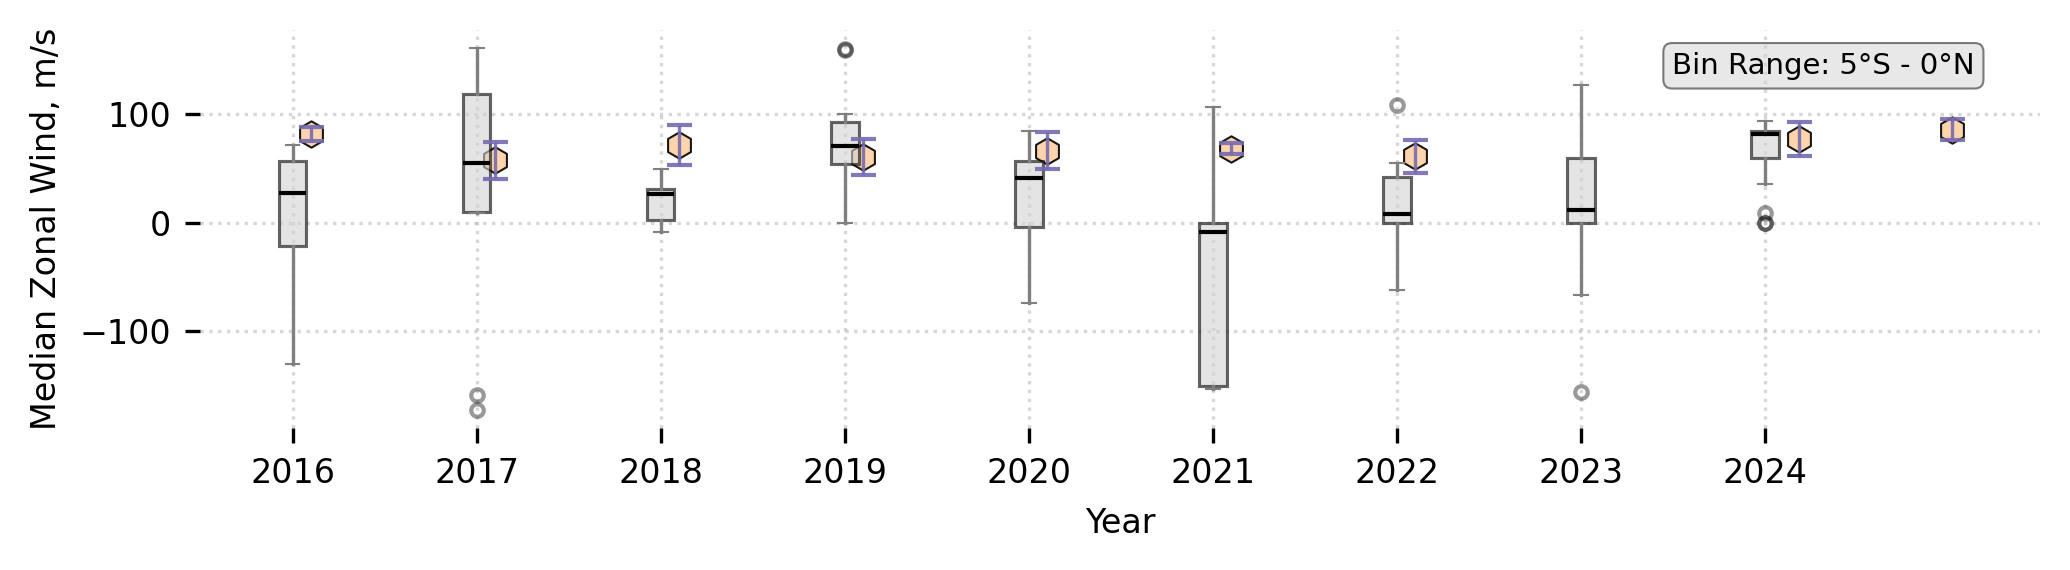

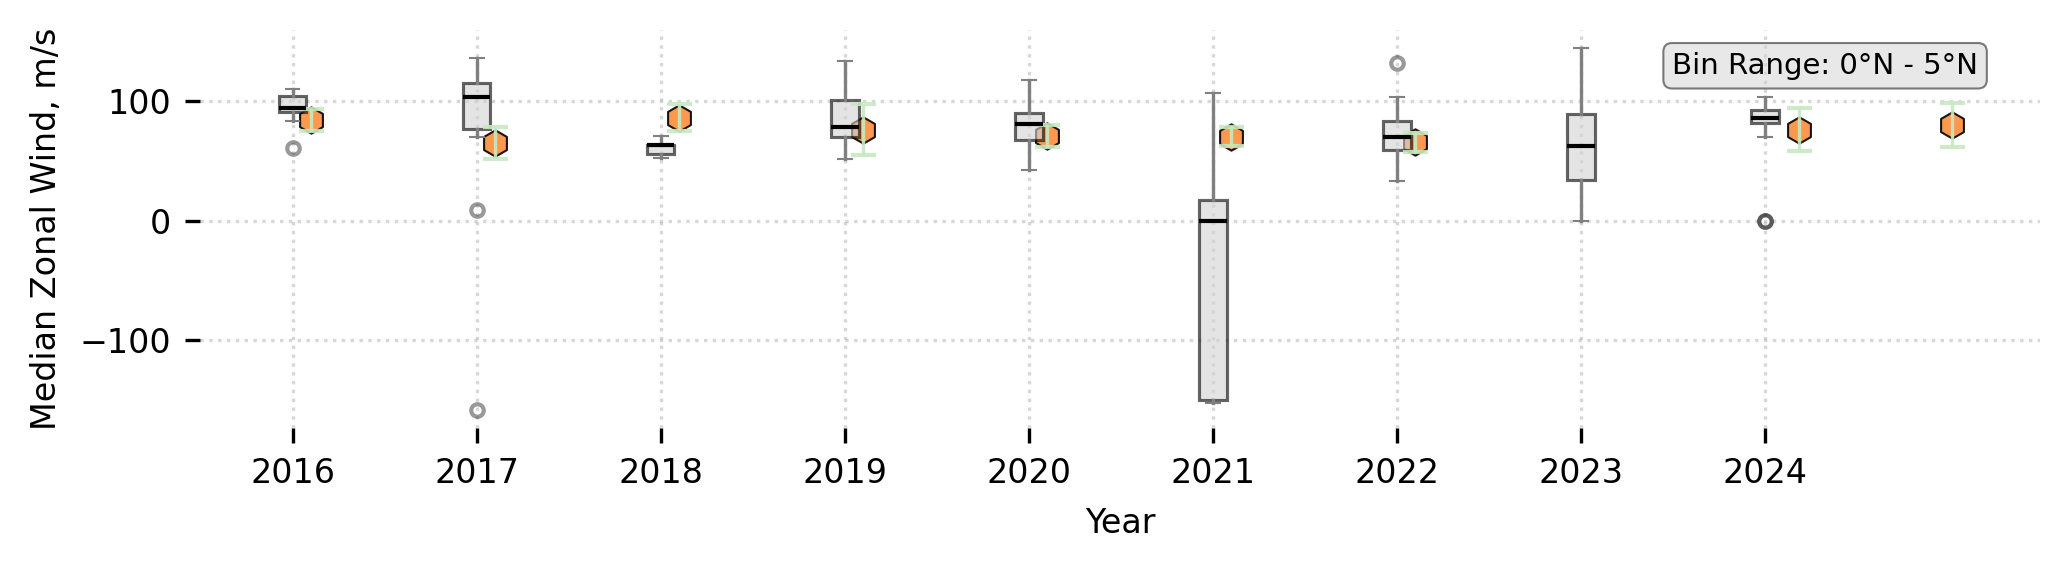

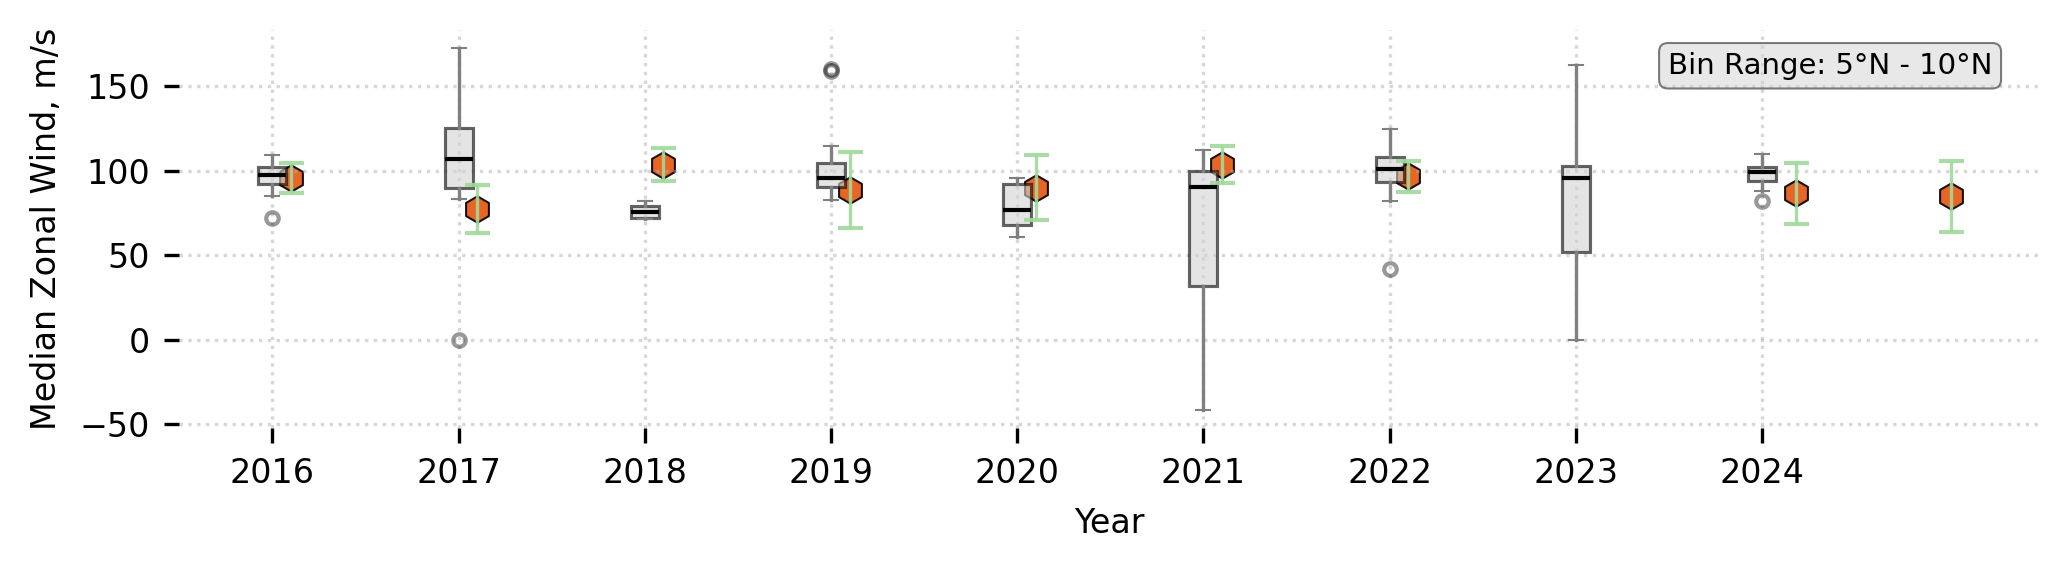

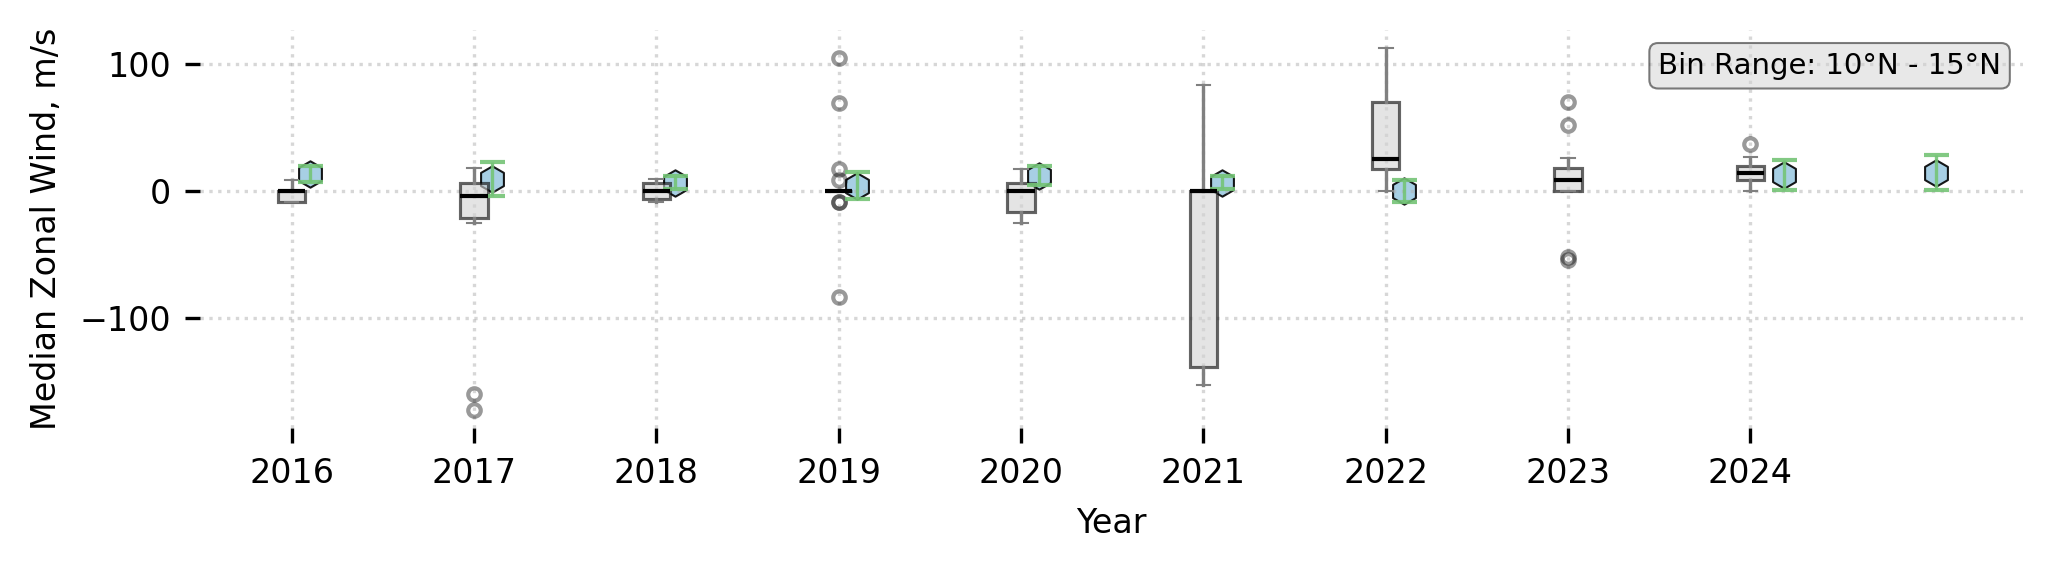

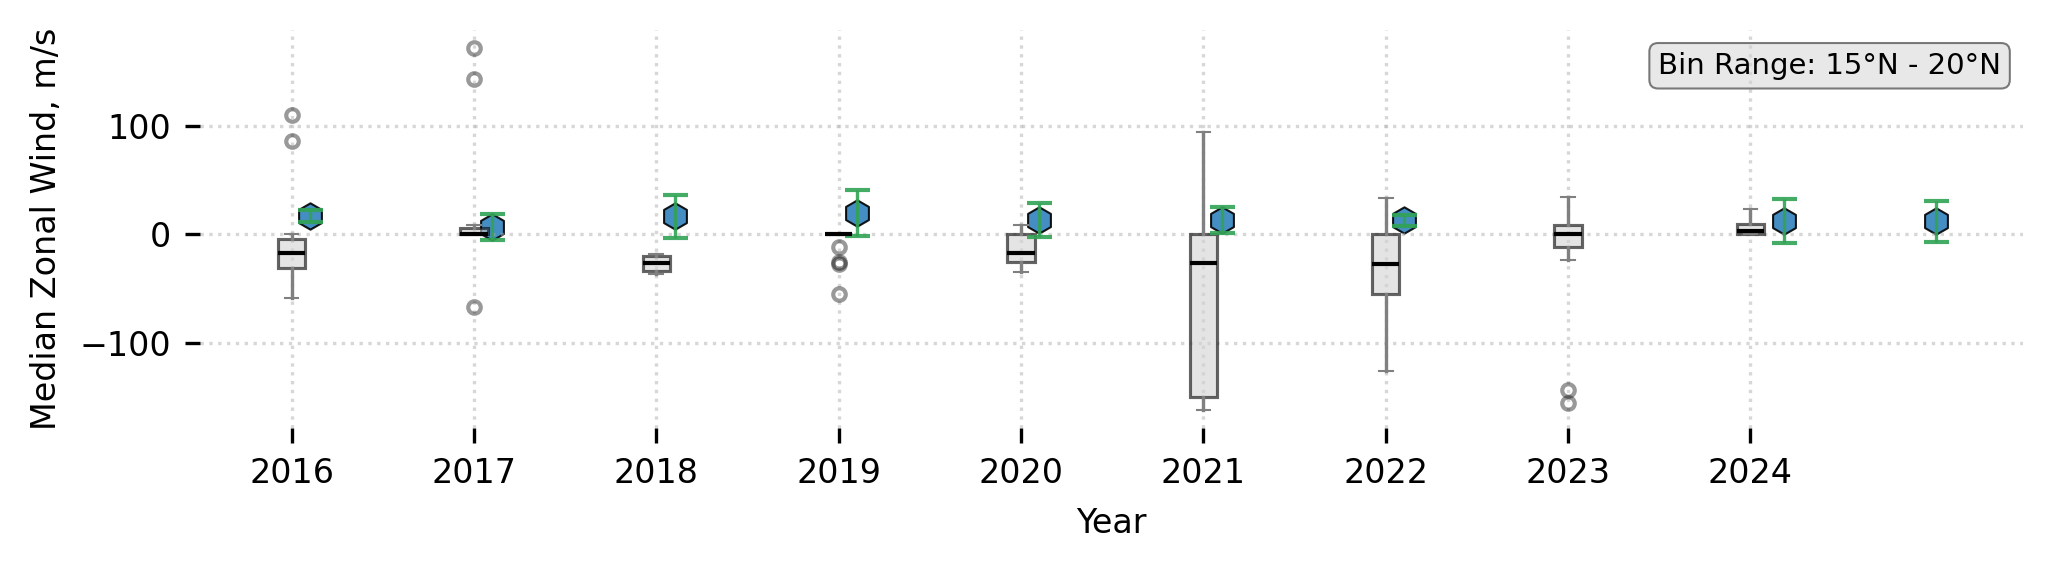

In [29]:
%matplotlib inline

bins_hst = np.arange(-40., 21., 5)
bin_centers = 0.5 * (bins_hst[:-1] + bins_hst[1:])  # Midpoints for coloring
offset = 0.0
# Create the normalizer and colormap explicitly
cmap_str = 'tab20c_r'
norm = mpl.colors.Normalize(vmin=bins_hst.min(), vmax=bins_hst.max())
cmap = plt.get_cmap(cmap_str)
offset = 0.1

for bh in range(len(bins_hst[:-1])):
    fig = plt.figure(figsize=(7,2), dpi=300)
    ax = fig.add_subplot(111)
    # year_vals, wind_vals = [], []  # store for this bin
    # Compute color explicitly for this bin
    color_test = cmap(norm(bin_centers[bh]))  # RGBA tuple
    hex_color = mcolors.to_hex(hex_color_arr[bh, :])

    # Add the IR dataset (with IRTF years)
    for i, iy in enumerate(year_arr):
        year_vals, wind_vals = [], []  # store for this bin
        for f in range(len(IR_dataframe[i]["corr1D_list"])):
            zwp_in_cent_i = IR_dataframe[i]["lat_array_used"][f][0, :]
            strt_ind, _ = ZWP_Class.closestIndex2Lat(zwp_in_cent_i, bins_hst[:-1][bh])
            end_ind,  _ = ZWP_Class.closestIndex2Lat(zwp_in_cent_i, bins_hst[1::][bh])
            wind_med = np.median(IR_dataframe[i]["corr1D_list"][f][0, :][strt_ind:end_ind+1])
            lat_med  = np.median(zwp_in_cent_i[strt_ind:end_ind+1])
            
            wind_vals.append(wind_med)
            year_vals.append(year_arr[i])
        
        year_vals = np.array(year_vals)
        wind_vals = np.array(wind_vals)
        unique_years = np.unique(year_vals)
        box_data = [wind_vals[year_vals == y] for y in unique_years] # each array holds all the wind measurements for one specific year

        # Add boxplots slightly offset horizontally for visibility
        ax.boxplot(
            box_data,
            positions=unique_years,
            widths=0.15,                    # thin boxes
            patch_artist=True,
            boxprops=dict(facecolor='lightgray', color='k', alpha=0.6, linewidth=0.75),
            medianprops=dict(color='k', linewidth=1.0),
            whiskerprops=dict(color='gray', linewidth=0.8),
            capprops=dict(color='gray', linewidth=0.5),
            flierprops=dict(marker='o', markersize=3, alpha=0.4)
        )

    # Add HST dataset (with HST years)
    for i, iy in enumerate(year_arr_hst):
        zwp_in_cent_i = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[i]['LAT']))
        strt_ind, _ = ZWP_Class.closestIndex2Lat(zwp_in_cent_i, bins_hst[:-1][bh])
        end_ind,  _ = ZWP_Class.closestIndex2Lat(zwp_in_cent_i, bins_hst[1::][bh])
        wind_med = np.median(HST_ZWP_list[i]['FMZW'][strt_ind:end_ind+1])
        lat_med  = np.median(zwp_in_cent_i[strt_ind:end_ind+1])
        # year_vals.append(year_arr_hst[i])
        # wind_vals.append(wind_med)
        
        err_i = HST_ZWP_list[i]['ERROR'][strt_ind:end_ind+1]
        N = len(err_i)
        err_scatter = np.max(abs(err_i)) #np.median(err_i) # RMS of errors
        # uncertainty on the median of the bin
        err_median = 1.253 * err_scatter / np.sqrt(N) # uncertainty on the median

        im1 = ax.scatter(
            year_arr_hst[i] + offset,
            wind_med,
            marker='h',
            c=[bin_centers[bh]],    # use bin center value for color mapping
            cmap=cmap_str,
            vmin=bins_hst.min(),
            vmax=bins_hst.max(),
            s=40,
            alpha=0.9,
            edgecolor='k',
            linewidths=0.5
        )

        # (A) Larger vertical bars: scatter of measurements
        ax.errorbar(
            year_arr_hst[i] + offset, wind_med, yerr=err_scatter,
            fmt='none', ecolor=hex_color, elinewidth=0.8, alpha=0.9,
            capsize=3, zorder=2, label='Measurement Scatter (RMS)'
        )

    label_text = f"Bin Range: {lat_label(bins_hst[:-1][bh])} - {lat_label(bins_hst[1::][bh])}"
    ax.text(0.80, 0.875, label_text, transform=ax.transAxes, fontsize=7,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5, linewidth=0.5))

    plt.xlabel("Year", fontsize=8)
    plt.ylabel("Median Zonal Wind, m/s", fontsize=8)
    plt.gca().tick_params('both', labelsize=8)
    plt.tight_layout()
    # plt.ylim(-65, 125)
    plt.gca().set_frame_on(False)
    plt.grid(True, ls=':', alpha=0.5)

plt.show()

In [30]:
plt.cm.tab20c_r(bh / (len(bins_hst[1::]))), bin_centers.shape

((np.float64(0.4196078431372549),
  np.float64(0.6823529411764706),
  np.float64(0.8392156862745098),
  np.float64(1.0)),
 (12,))

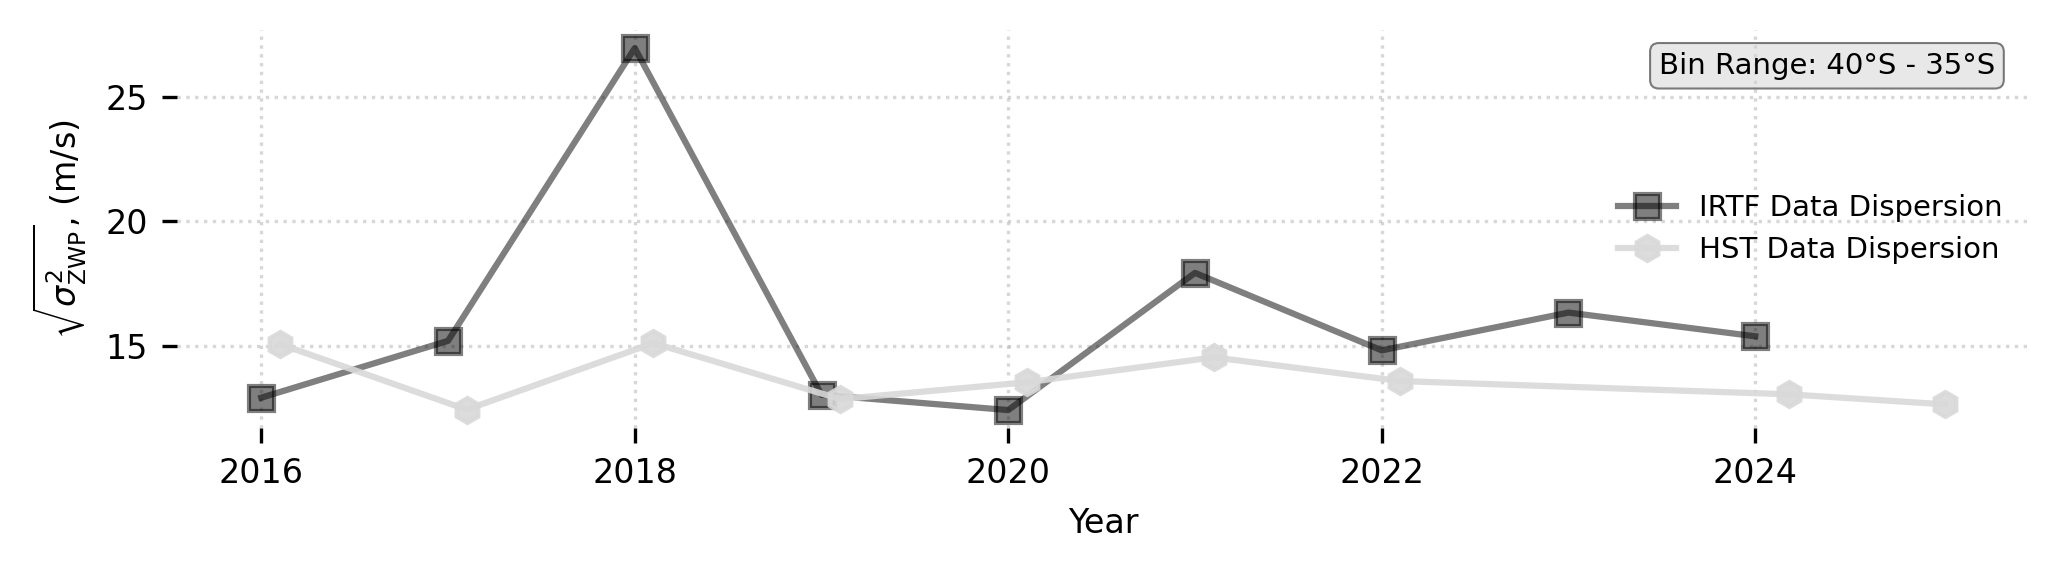

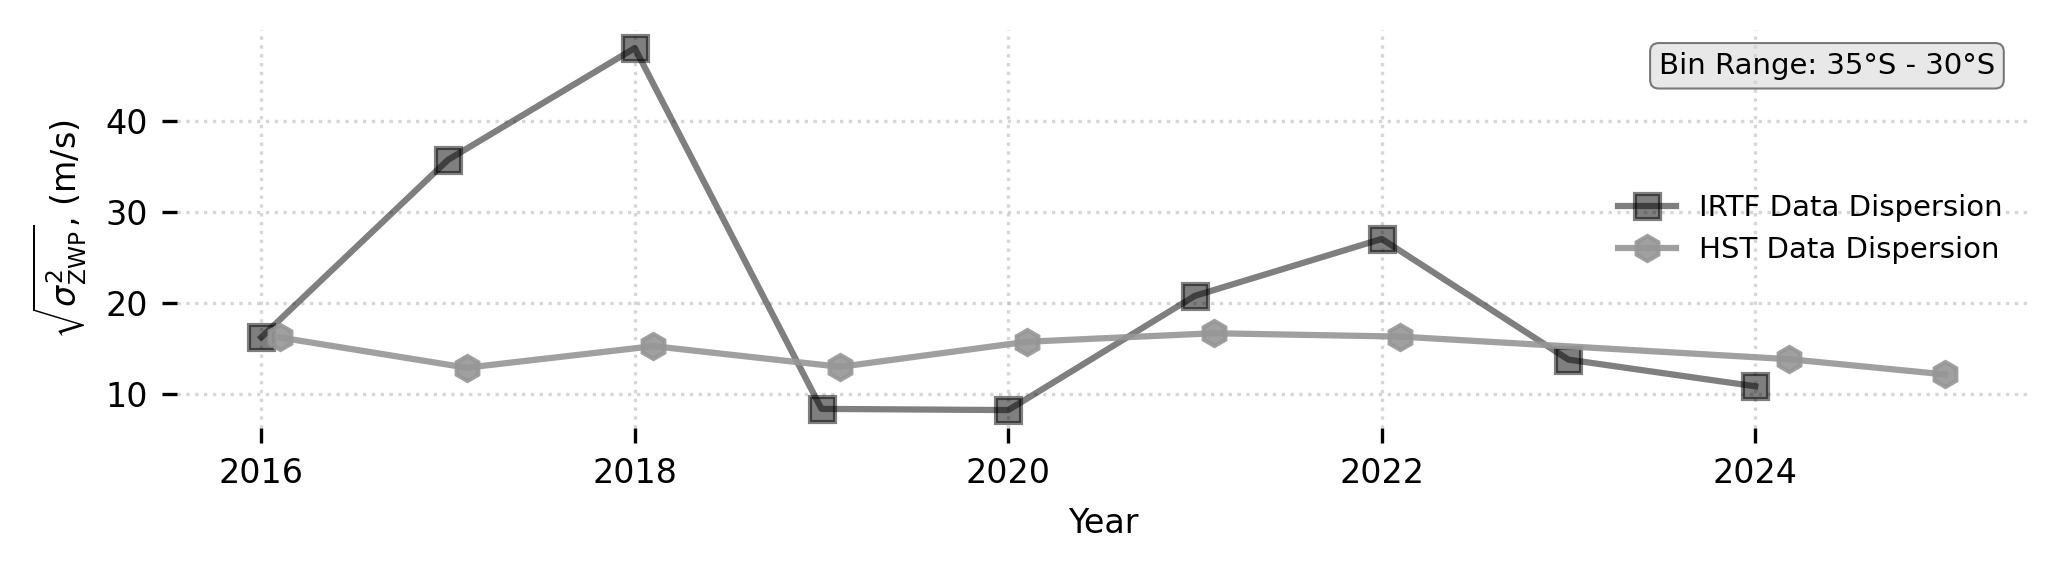

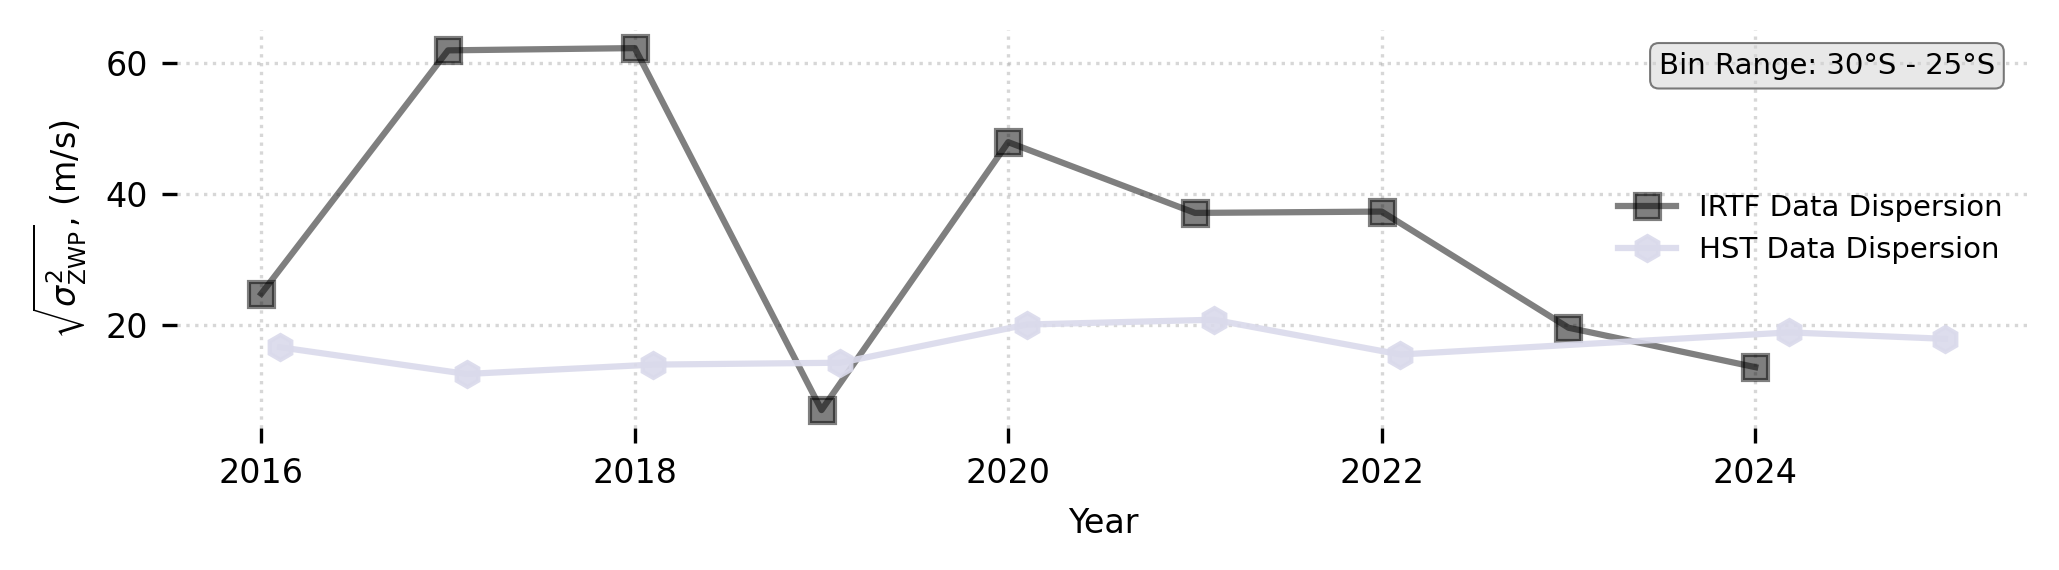

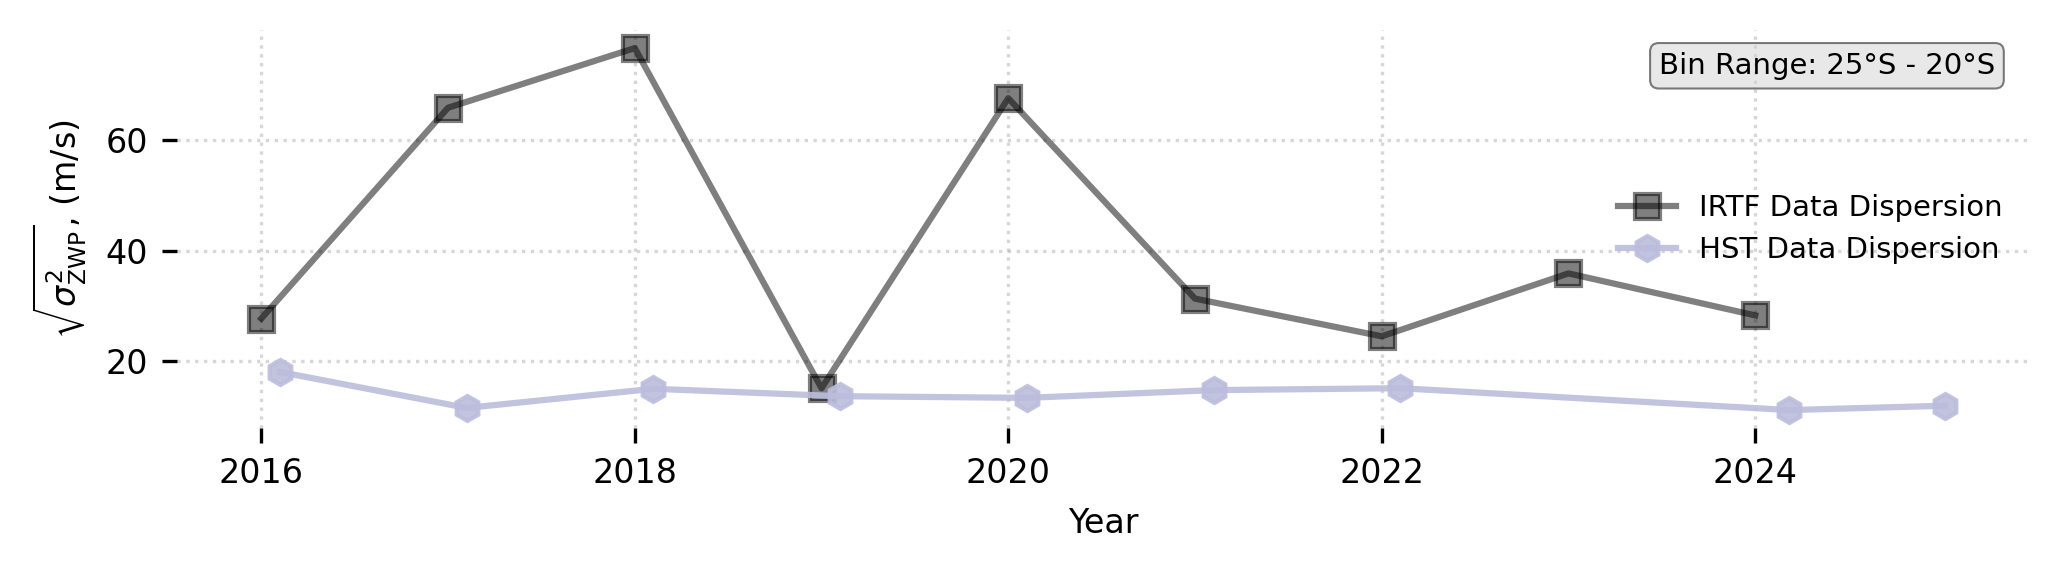

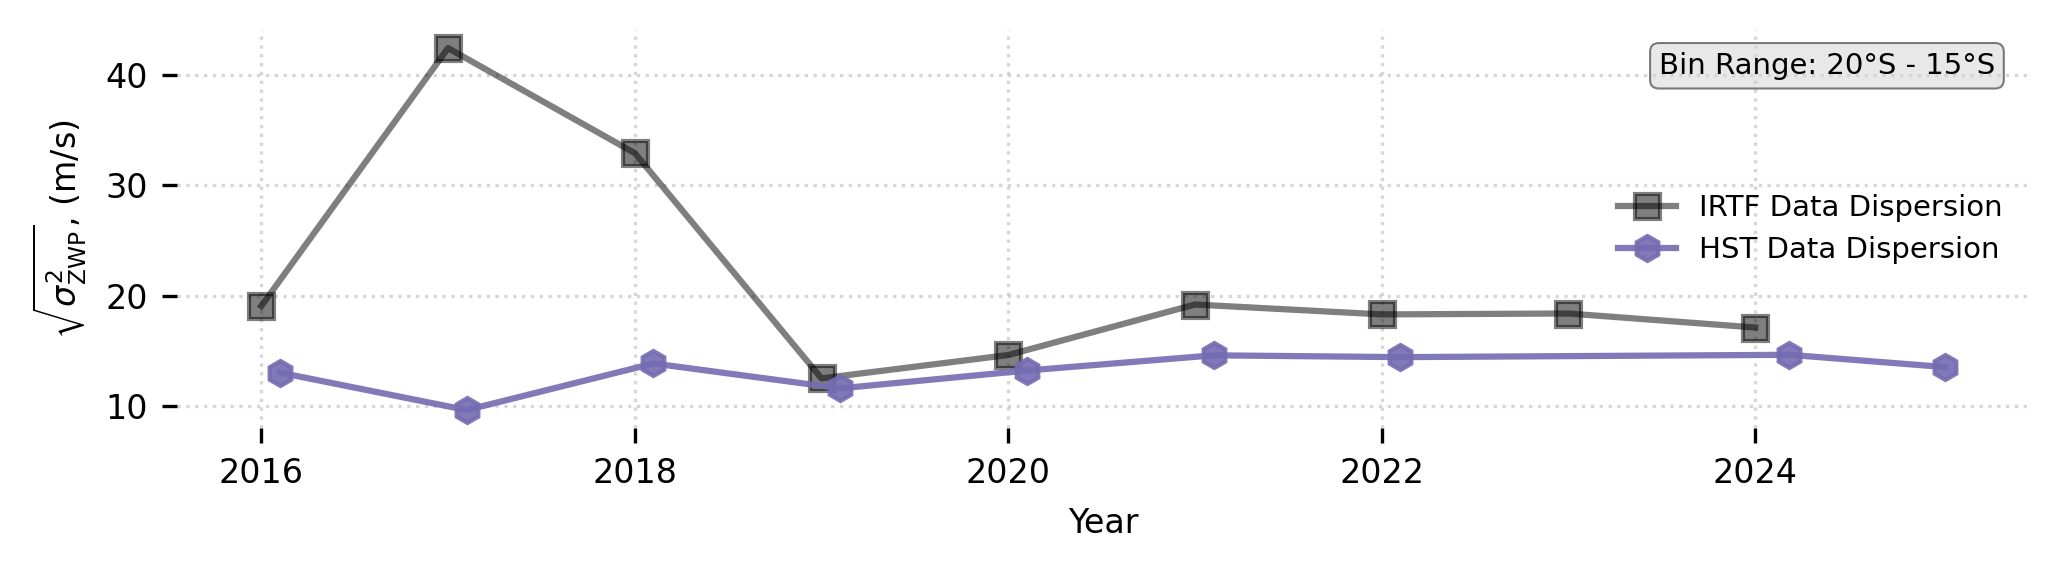

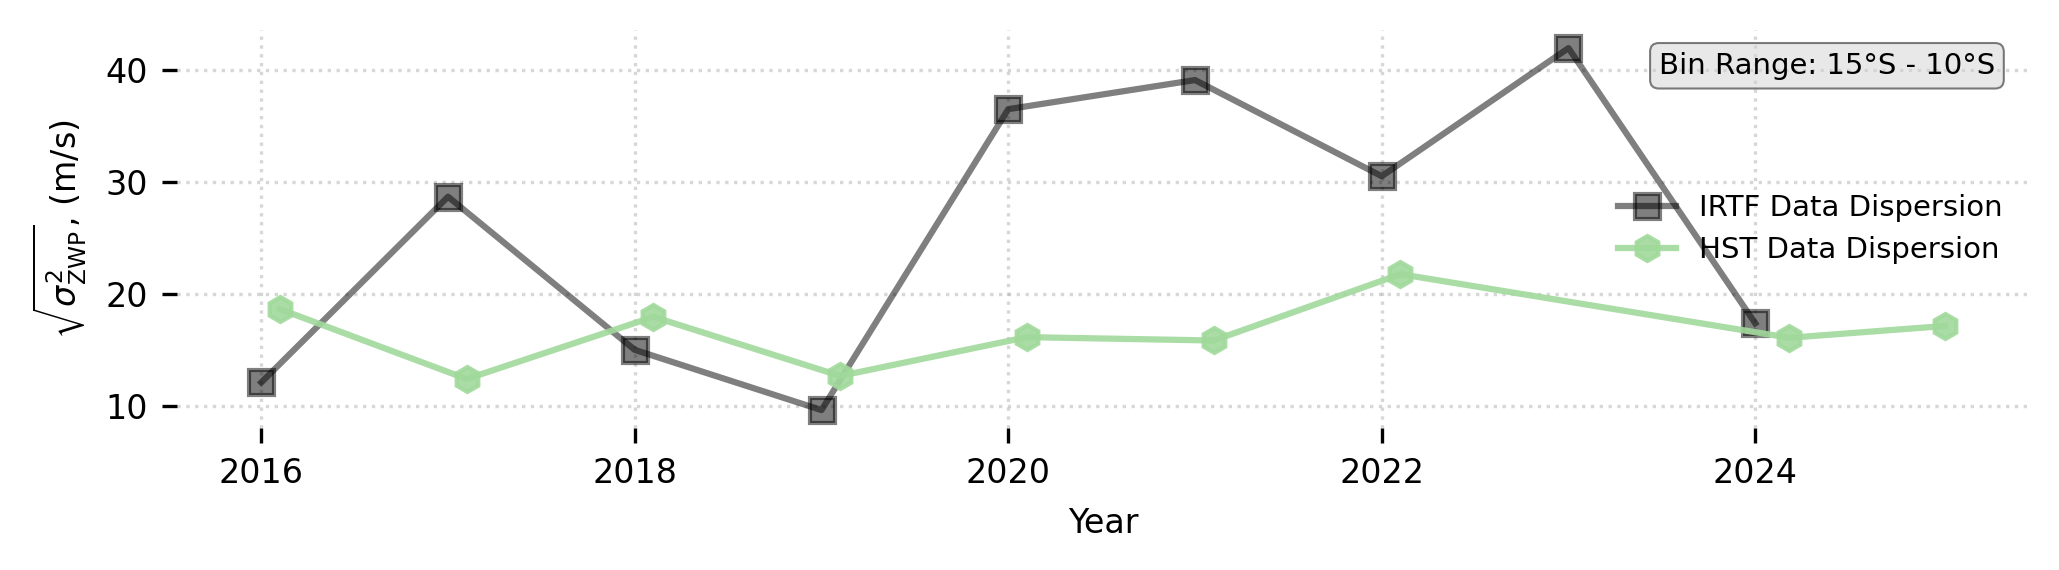

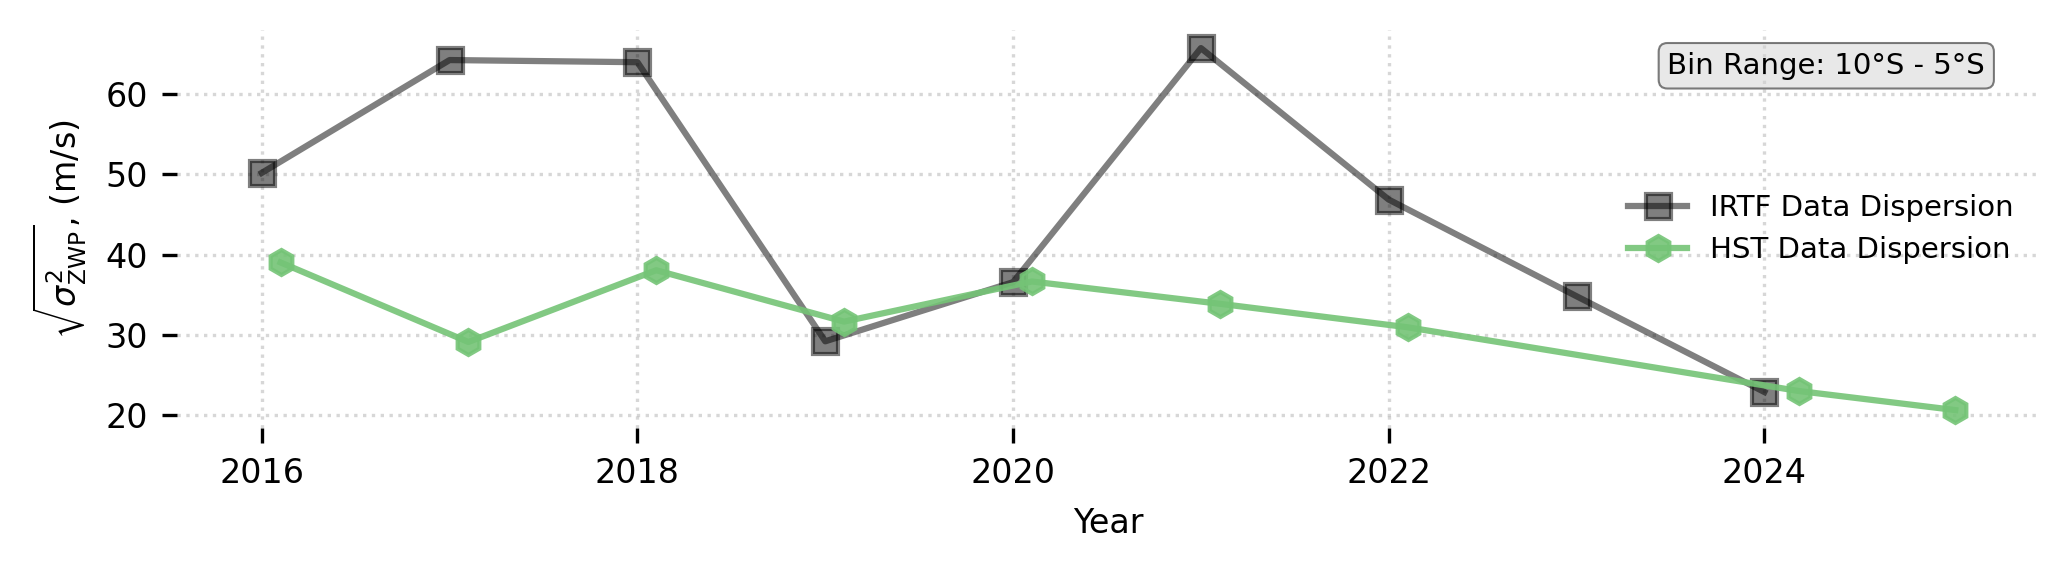

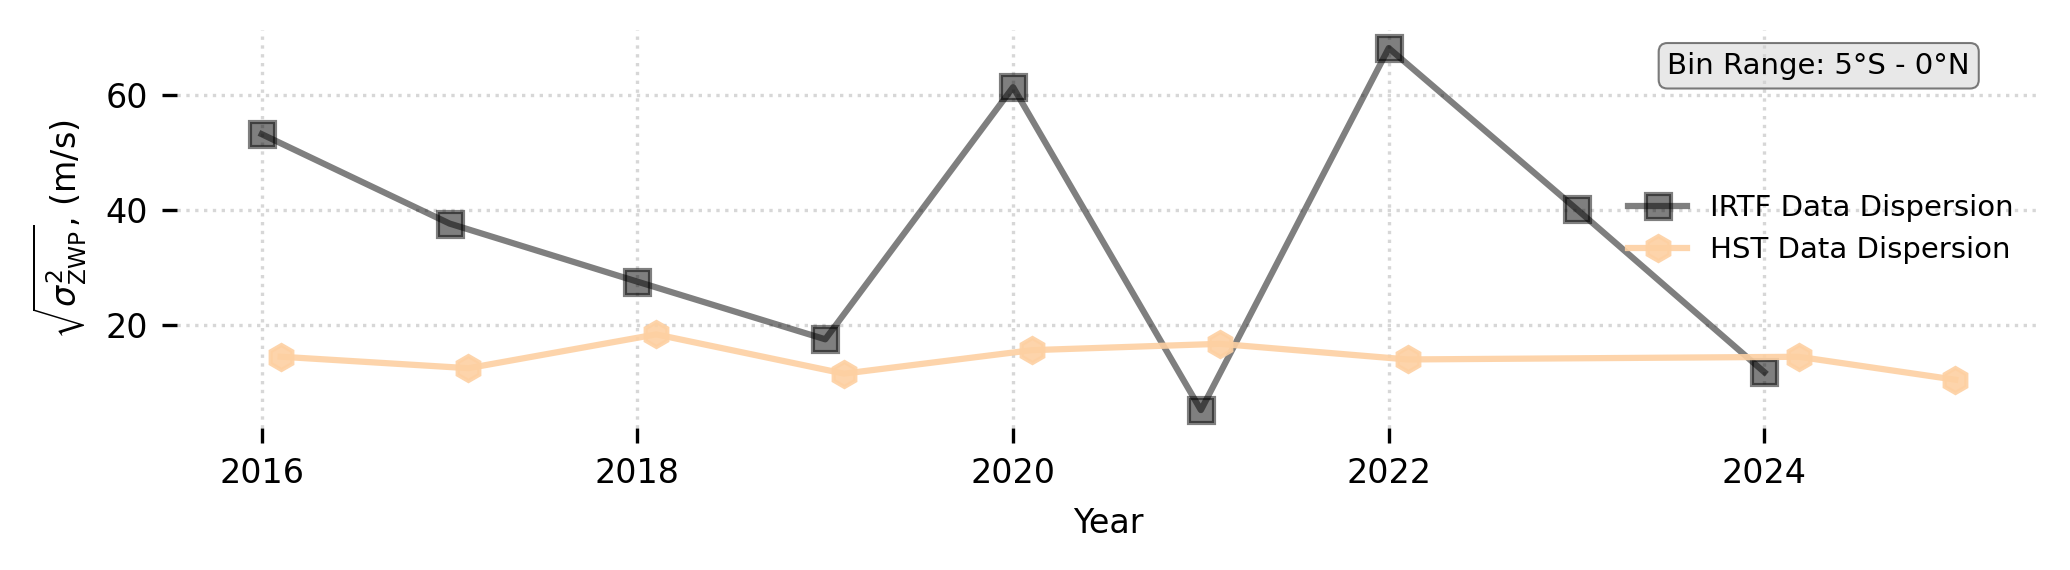

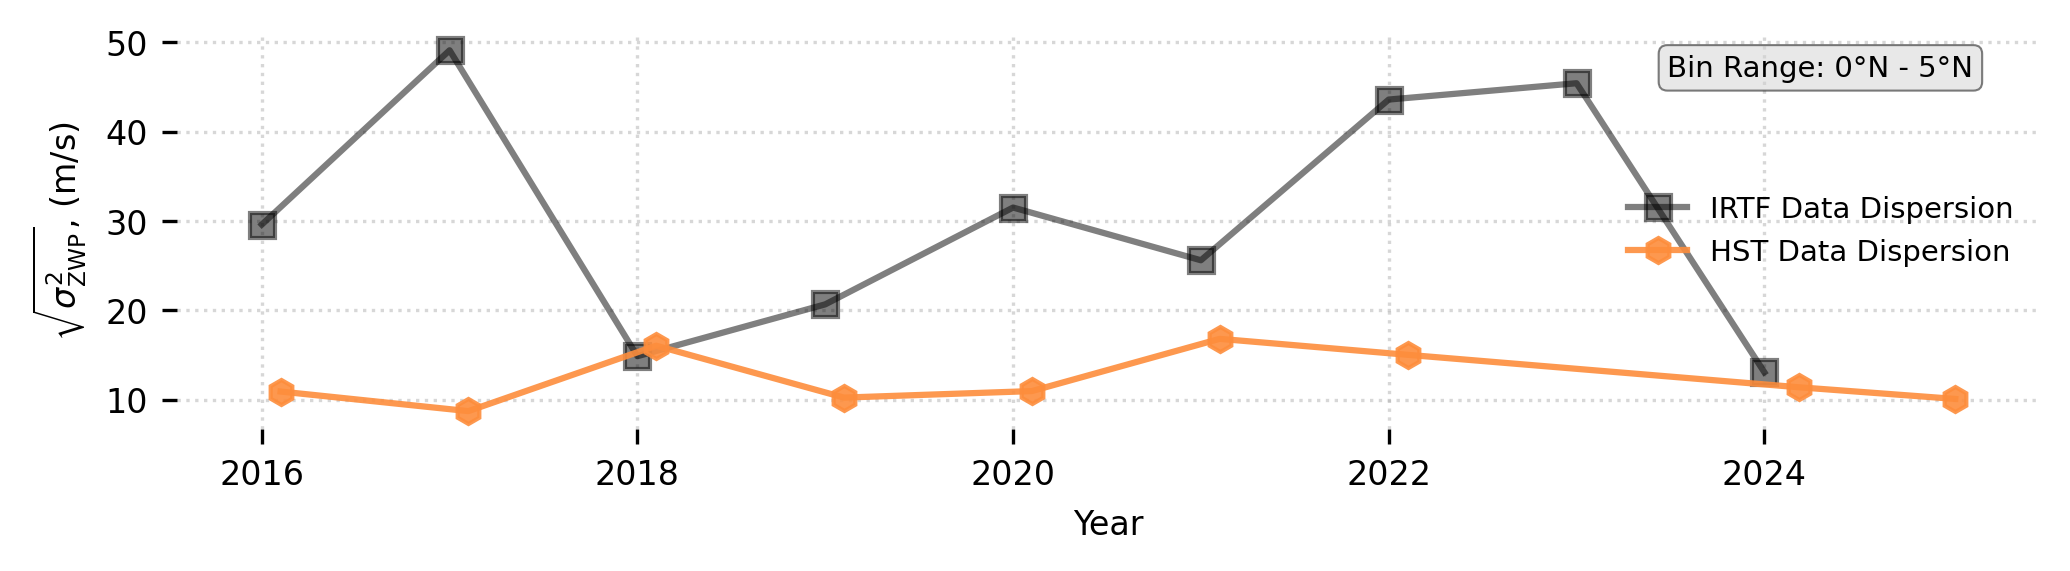

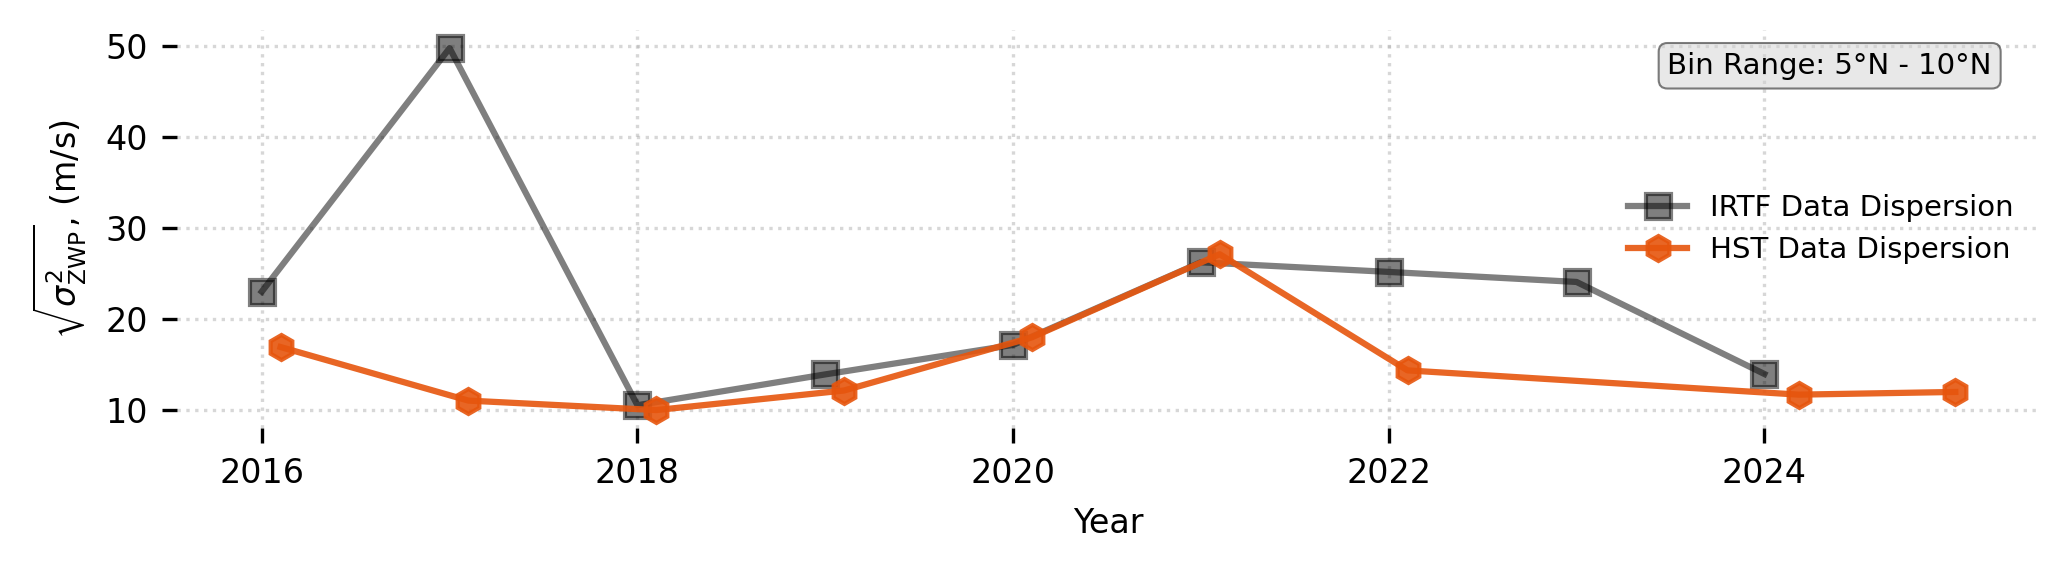

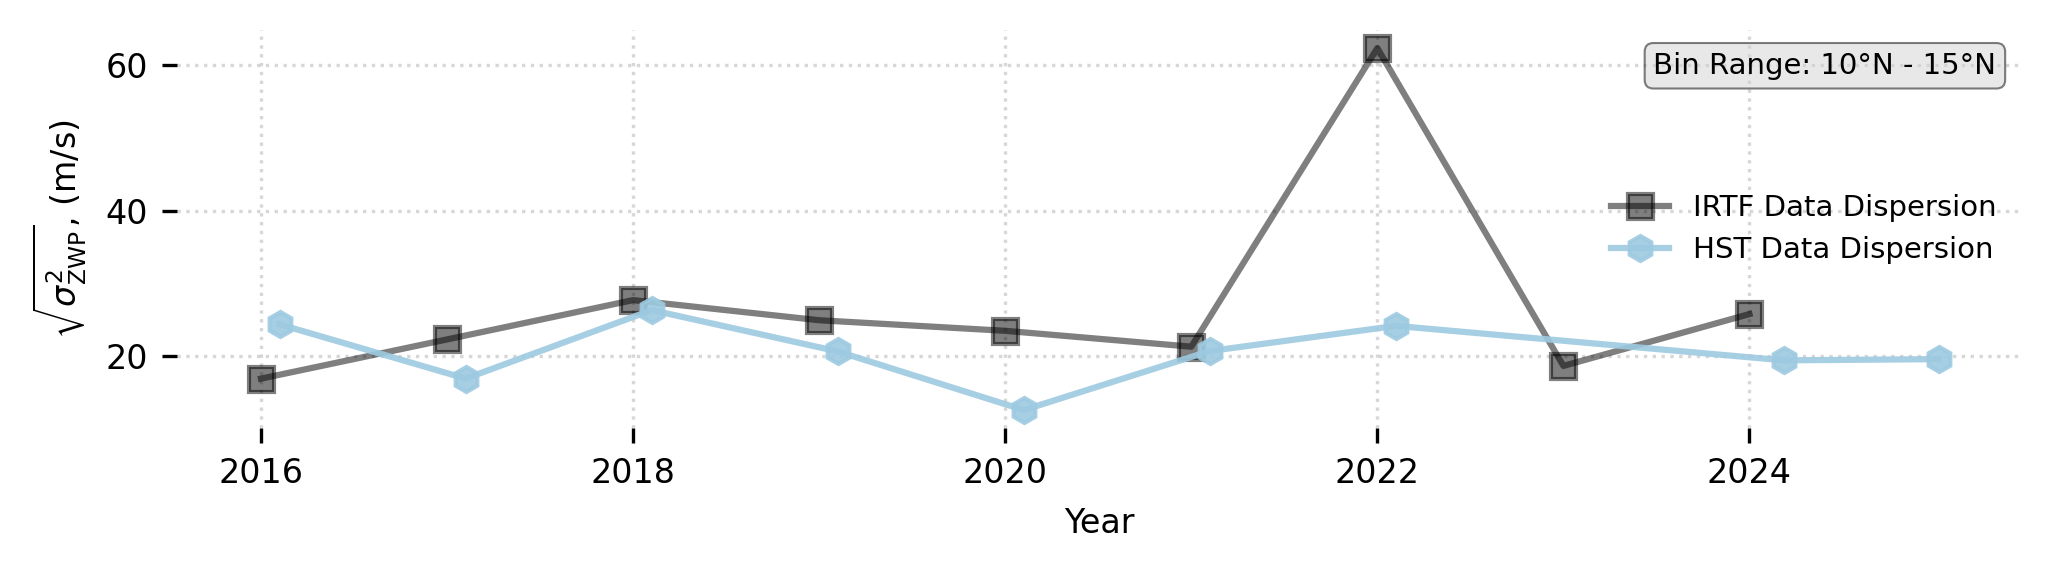

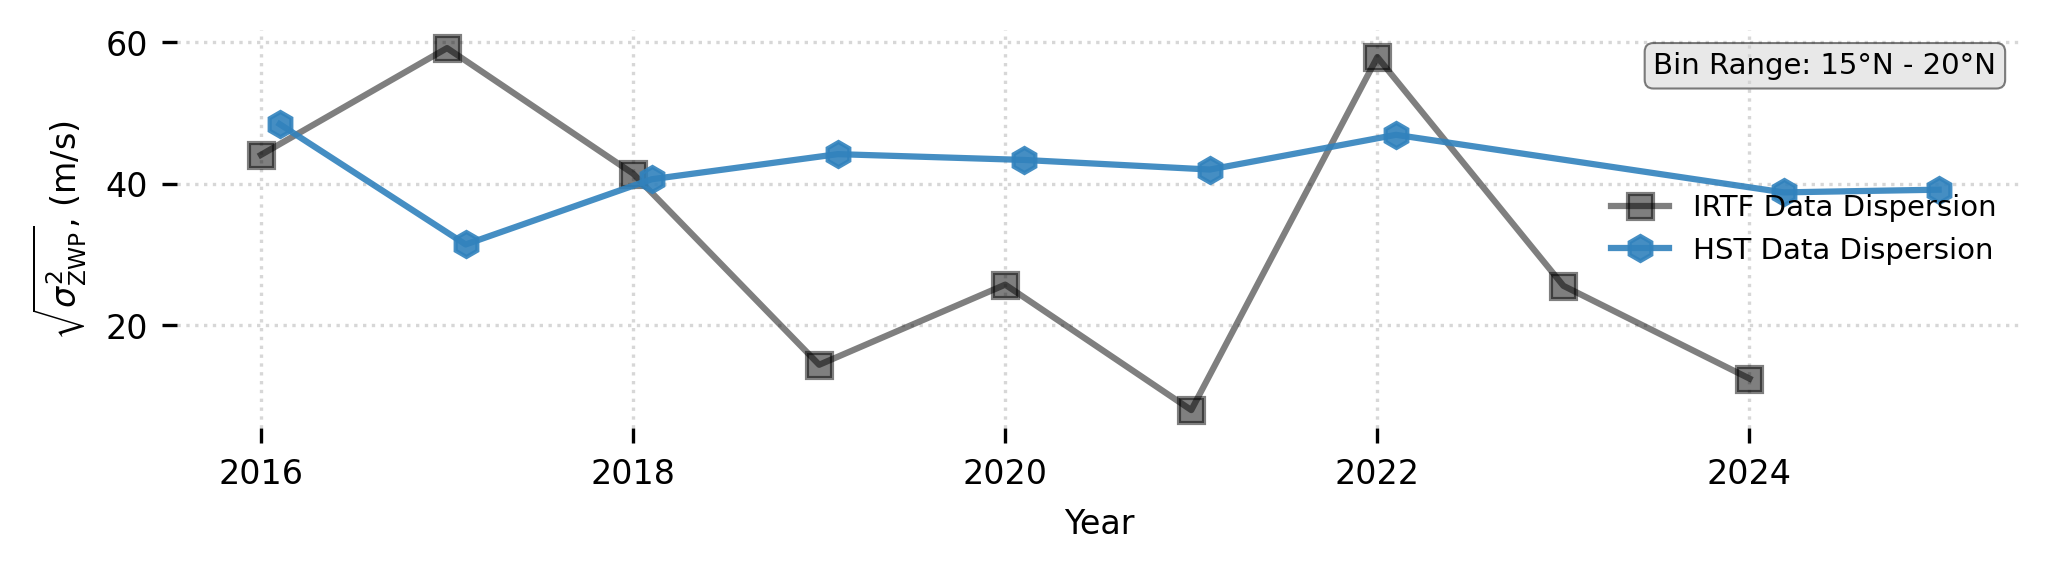

In [31]:
%matplotlib inline

bins_hst = np.arange(-40., 21., 5)
bin_centers = 0.5 * (bins_hst[:-1] + bins_hst[1:])
offset = 0.1

cmap_str = 'tab20c_r'
norm = mpl.colors.Normalize(vmin=bins_hst.min(), vmax=bins_hst.max())
cmap = plt.get_cmap(cmap_str)

for bh in range(len(bins_hst[:-1])):
    fig, ax = plt.subplots(figsize=(7, 2), dpi=300)
    color = cmap(norm(bin_centers[bh]))
    hex_color = mcolors.to_hex(color)

    # --------------------------
    # IRTF: compute variance per year
    # --------------------------
    year_vals, var_vals = [], []
    for i, iy in enumerate(year_arr):
        bin_variances = []
        for f in range(len(IR_dataframe[i]["corr1D_list"])):
            zwp_in_cent_i = IR_dataframe[i]["lat_array_used"][f][0, :]
            strt_ind, _ = ZWP_Class.closestIndex2Lat(zwp_in_cent_i, bins_hst[:-1][bh])
            end_ind,  _ = ZWP_Class.closestIndex2Lat(zwp_in_cent_i, bins_hst[1::][bh])
            data_bin = IR_dataframe[i]["corr1D_list"][f][0, :][strt_ind:end_ind+1]
            if len(data_bin) > 1:
                bin_variances.append(np.var(data_bin))
        # if bin_variances:
        year_vals.append(year_arr[i])
        var_vals.append(np.median(bin_variances))  # or np.mean(bin_variances)

    if len(year_vals) > 0:
        ax.plot(year_vals, np.sqrt(var_vals), 's-', color='k', alpha=0.5, label='IRTF Data Dispersion')

    # --------------------------
    # HST: compute variance per year
    # --------------------------
    year_vals_hst, var_vals_hst = [], []
    for i, iy in enumerate(year_arr_hst):
        zwp_in_cent_i = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[i]['LAT']))
        strt_ind, _ = ZWP_Class.closestIndex2Lat(zwp_in_cent_i, bins_hst[:-1][bh])
        end_ind,  _ = ZWP_Class.closestIndex2Lat(zwp_in_cent_i, bins_hst[1::][bh])
        data_bin = HST_ZWP_list[i]['FMZW'][strt_ind:end_ind+1]
        if len(data_bin) > 1:
            year_vals_hst.append(year_arr_hst[i])
            var_vals_hst.append(np.var(data_bin))

    if len(year_vals_hst) > 0:
        ax.plot(
            np.array(year_vals_hst) + offset,
            np.sqrt(var_vals_hst),
            'h-',
            color=hex_color,
            # edgecolor='k',
            # linewidths=0.5,
            alpha=0.9,
            label='HST Data Dispersion'
        )

    label_text = f"Bin Range: {lat_label(bins_hst[:-1][bh])} - {lat_label(bins_hst[1::][bh])}"
    ax.text(
        0.80, 0.875, label_text,
        transform=ax.transAxes, fontsize=7,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5, linewidth=0.5)
    )

    ax.set_xlabel("Year", fontsize=8)
    ax.set_ylabel(r"$\sqrt{\sigma^2_{\rm ZWP}}$, (m/s)", fontsize=8)
    ax.tick_params(labelsize=8)
    plt.gca().tick_params('both', labelsize=8)
    ax.set_frame_on(False)
    ax.grid(True, ls=':', alpha=0.5)
    ax.legend(fontsize=7, loc='center right', frameon=False)

    plt.tight_layout()


plt.show()


In [32]:
bin_variances, var_vals

([np.float64(216.42214762337935),
  np.float64(892.6501245897297),
  np.float64(184.86192465410963),
  np.float64(335.43901179923074),
  np.float64(64.68094806825385),
  np.float64(1037.946873868863),
  np.float64(74.71709857674671),
  np.float64(64.93865959625788),
  np.float64(28.870843026598276),
  np.float64(97.58163301868773),
  np.float64(363.37273716497276),
  np.float64(86.59835224796115),
  np.float64(545.9027810883366),
  np.float64(607.6645321316037),
  np.float64(85.62923966188504),
  np.float64(44.17949941042955),
  np.float64(125.14077283904085),
  np.float64(1363.1599453200513),
  np.float64(336.2493827557441),
  np.float64(120.17217419223051)],
 [np.float64(1944.0427992423124),
  np.float64(3503.695796729219),
  np.float64(1716.8409929059467),
  np.float64(207.36645313898643),
  np.float64(662.2878158358533),
  np.float64(63.88809376406178),
  np.float64(3354.3668432387362),
  np.float64(653.635420464167),
  np.float64(155.00134874657525)])

0      -90.000000
1      -89.885644
2      -89.771288
3      -89.656932
4      -89.542577
          ...    
1795    89.428223
1796    89.542577
1797    89.656932
1798    89.771288
1799    89.885644
Name: LAT, Length: 1800, dtype: float64


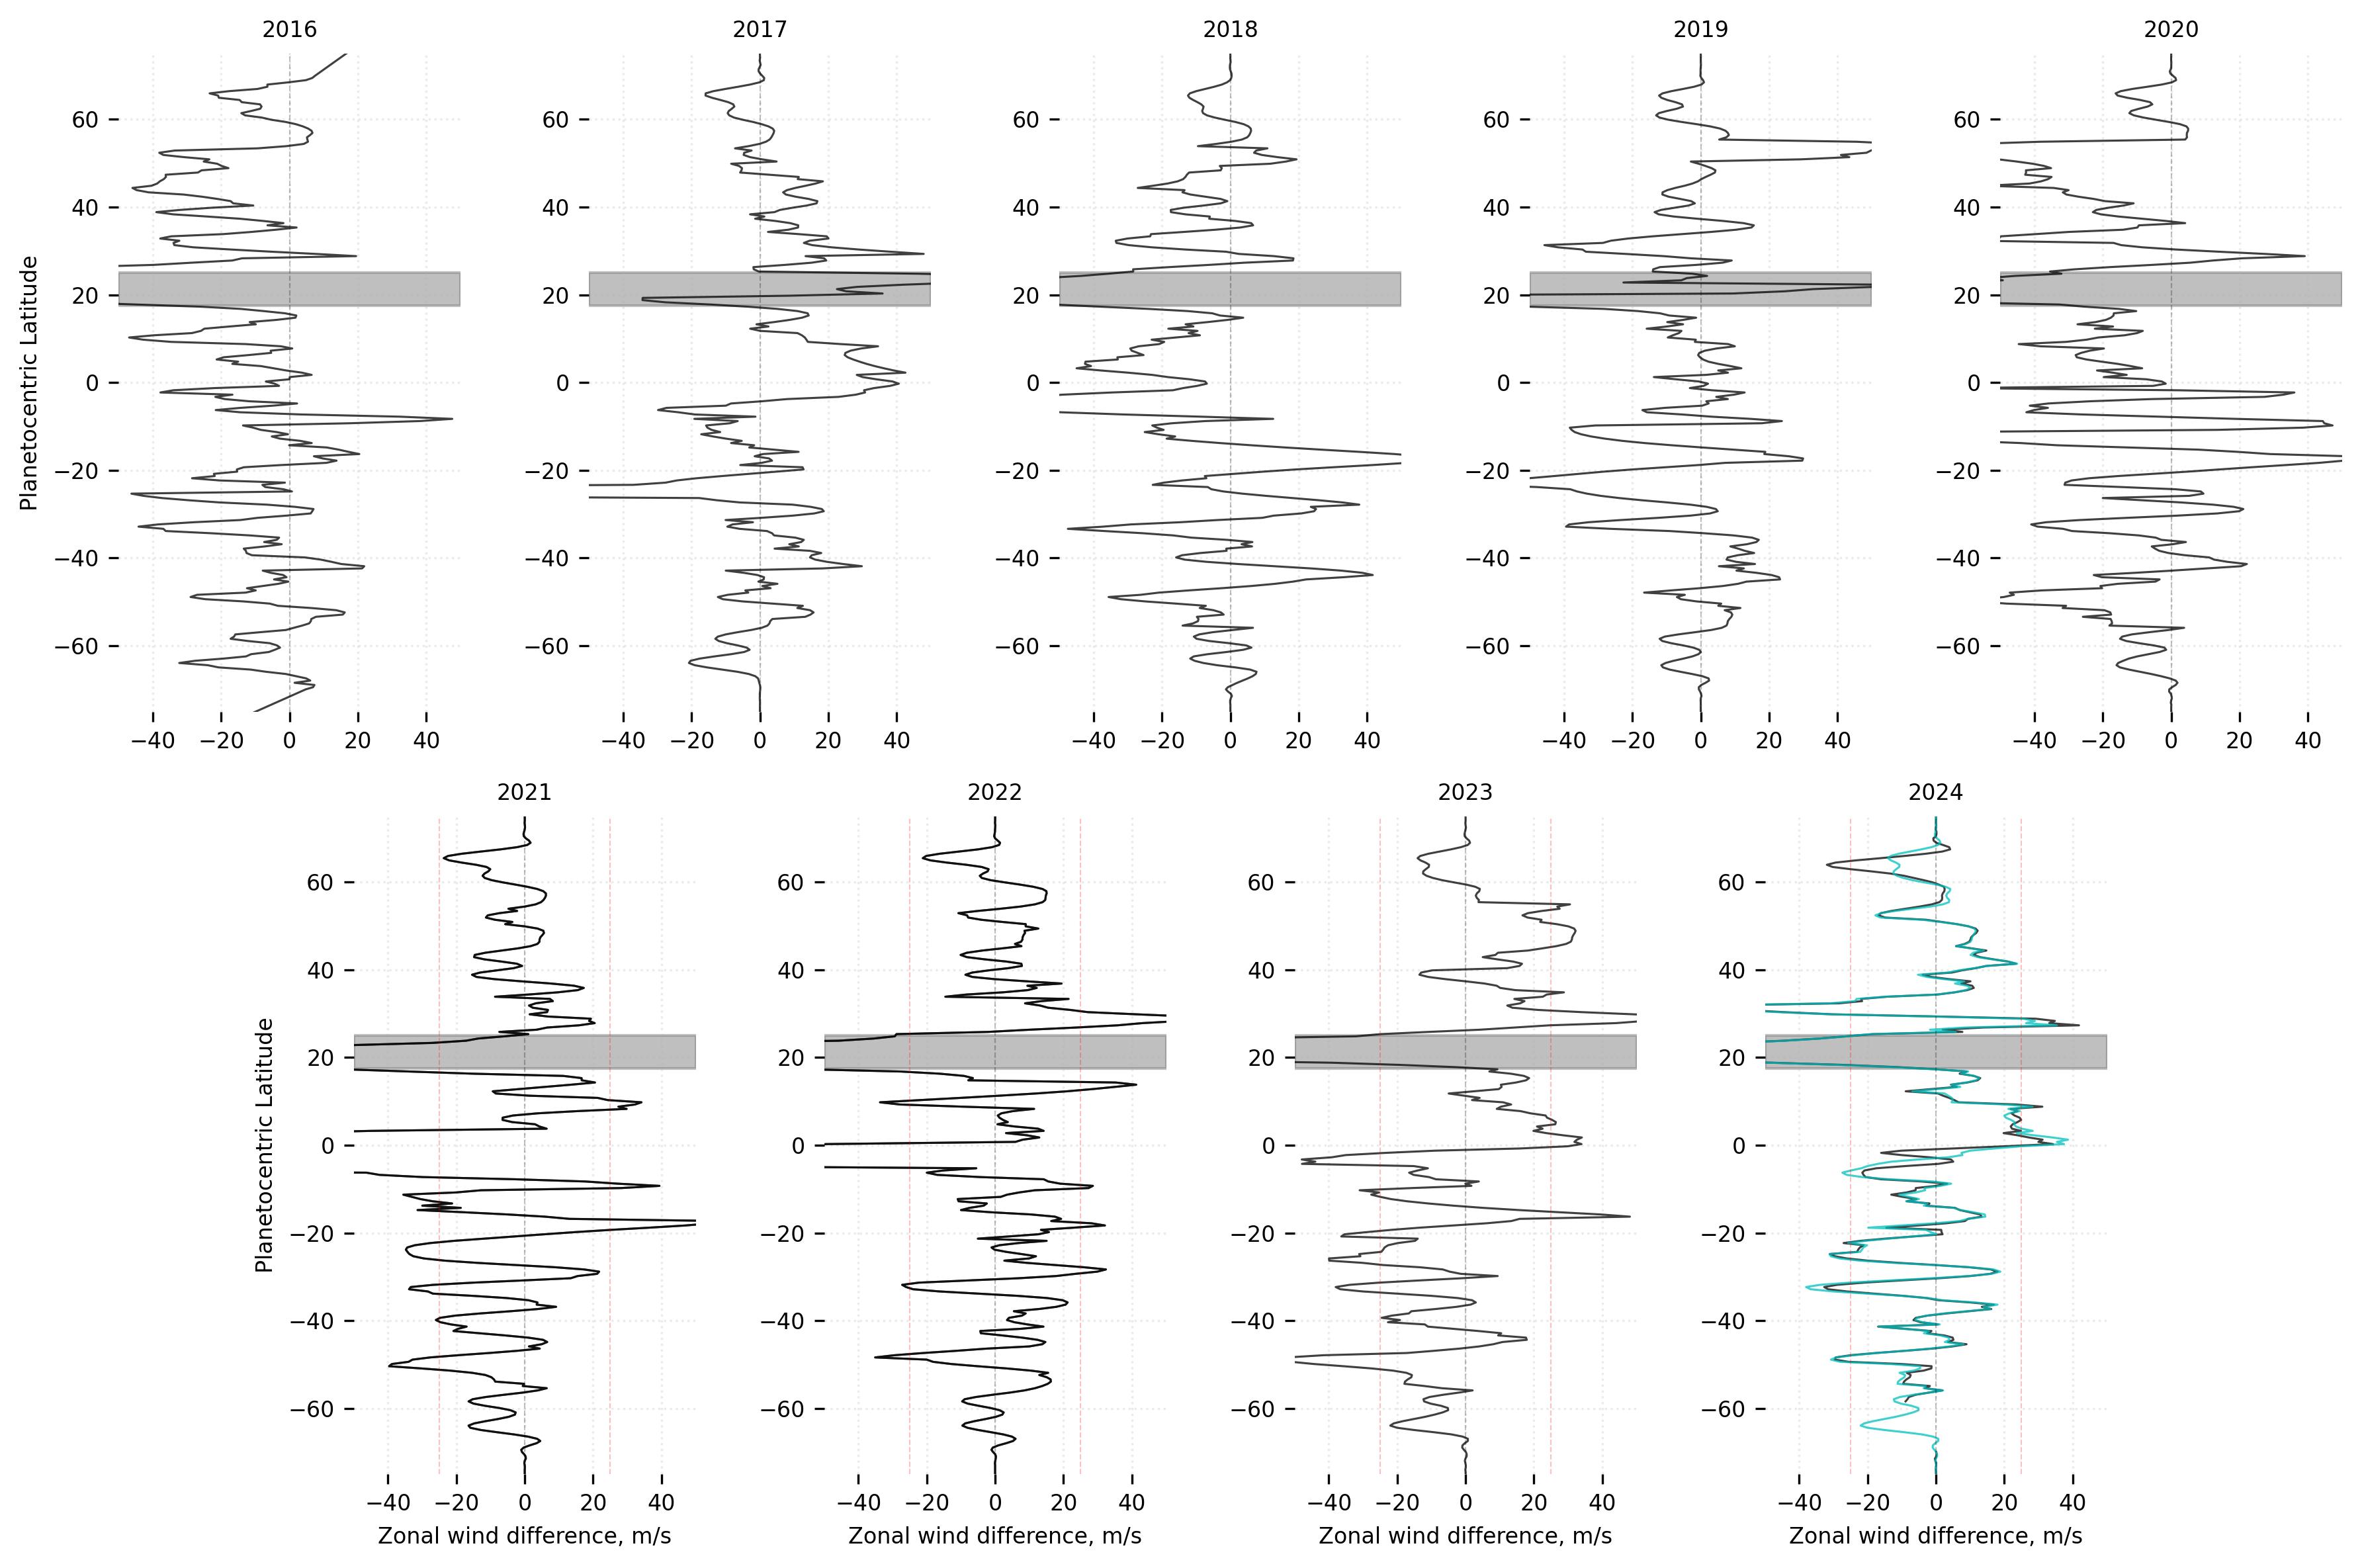

In [33]:
print(np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[j]['LAT'])))
ZWP_Class.getInterpolatedArray(np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[j]['LAT'])),
                               HST_ZWP_list[j]['FMZW'], ZWP_2024['lat_array_used'])


%matplotlib inline
fig = plt.figure(figsize=(12, 8), dpi=300)
gs = GridSpec(2, 10, figure=fig)  # finer grid (10 columns)

axes = []
ylim = 75
xlim = 50

# Top row: 5 plots (each spanning 2 columns)
for i in range(5):
    ax = fig.add_subplot(gs[0, 2*i:2*i+2])
    ax.set_title(str(year_arr[i]), fontsize=8)
    interpedHSTdata = ZWP_Class.getInterpolatedArray(np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[i]['LAT'])),
                                                    HST_ZWP_list[i]['FMZW'], ZWP_2024['lat_array_used'])
    ax.plot((ZWP_full[i, :] - interpedHSTdata), ZWP_2024['lat_array_used'], lw=0.75, alpha=0.75, color='k')
    # ax.plot(-abs(ZWP_full[i, :] - interpedHSTdata), ZWP_2024['lat_array_used'], lw=0.75, alpha=0.75, color='r')
    # ax.scatter(ZWP_full[i, :], ZWP_2024['lat_array_used'], marker='s', color='k', s=0.5, alpha=0.5)
    ax.axhspan(17.5, 25, color='gray', alpha=0.5)
    axes.append(ax)
    ax.set_ylim(-ylim, ylim)
    ax.set_xlim(-xlim, xlim)
    ax.vlines(0.0, -ylim, ylim, ls='dashed', lw=0.5, alpha=0.25, color='k')
    ax.set_frame_on(False)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.grid(True, ls=':', alpha=0.25)
    if i==0:
        ax.set_ylabel('Planetocentric Latitude', fontsize=8)

# Bottom row: 4 plots (each spanning 2 columns), centered
for i in range(4):
    j = i + 5
    ax = fig.add_subplot(gs[1, 1+2*i:1+2*i+2])
    ax.set_title(str(year_arr[j]), fontsize=8)
    if j!=7: # also handles j==8...
        interpedHSTdata = ZWP_Class.getInterpolatedArray(np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[j]['LAT'])),
                                                    HST_ZWP_list[j]['FMZW'], ZWP_2024['lat_array_used'])
        ax.plot((ZWP_full[j, :] - interpedHSTdata), ZWP_2024['lat_array_used'], lw=0.75, alpha=0.75, color='k')
        # ax.plot(-abs(ZWP_full[j, :] - interpedHSTdata), ZWP_2024['lat_array_used'], lw=0.75, alpha=0.75, color='r')
    if j==8:
        interpedHSTdata = ZWP_Class.getInterpolatedArray(np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[j-1]['LAT'])),
                                                    HST_ZWP_list[j-1]['FMZW'], ZWP_2024['lat_array_used'])
        ax.plot((ZWP_full[j, :] - interpedHSTdata), ZWP_2024['lat_array_used'], lw=0.75, alpha=0.75, color='c')
        # ax.plot(-abs(ZWP_full[j, :] - interpedHSTdata), ZWP_2024['lat_array_used'], lw=0.75, alpha=0.75, color='c')
    else:
        interpedHSTdata = ZWP_Class.getInterpolatedArray(np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_ZWP_list[j]['LAT'])),
                                                    HST_ZWP_list[j]['FMZW'], ZWP_2024['lat_array_used'])
        ax.plot((ZWP_full[j, :] - interpedHSTdata), ZWP_2024['lat_array_used'], lw=0.75, alpha=0.75, color='k')
        # ax.plot(-abs(ZWP_full[j, :] - interpedHSTdata), ZWP_2024['lat_array_used'], lw=0.75, alpha=0.75, color='r')
    ax.set_ylim(-ylim, ylim)
    ax.set_xlim(-xlim, xlim)
    ax.vlines(0.0, -ylim, ylim, ls='dashed', lw=0.5, alpha=0.25, color='k')
    ax.vlines(-25, -ylim, ylim, ls='dashed', lw=0.5, alpha=0.25, color='r')
    ax.vlines(25, -ylim, ylim, ls='dashed', lw=0.5, alpha=0.25, color='r')
    ax.axhspan(17.5, 25, color='gray', alpha=0.5)
    axes.append(ax)
    ax.set_frame_on(False)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.grid(True, ls=':', alpha=0.25)
    ax.set_xlabel('Zonal wind difference, m/s', fontsize=8)
    if i==0:
        ax.set_ylabel('Planetocentric Latitude', fontsize=8)

plt.tight_layout()
plt.show()

